In [8]:
# =====================================================================
# Cell 1: 数据读取 + 基于 time-diff 的 cycle / SOC / pulse role 筛选
# =====================================================================
# 新筛选逻辑：
#   1) 不再依赖固定 programme ID offset，而是按每个 ID 的时间段与相邻脉冲时间差识别 cycle；
#   2) 每个 cycle 理论上包含 4 个 pulse：
#          0: First_DCH_1p5A_excluded  1.5 A DCH，作为 cycle 起点，但后续剔除
#          1: Small_CHA_1              1.5 A CHA，用于参数提取
#          2: HighCurrent_DCH_3A       3.0 A DCH，用于参数提取
#          3: HighCurrent_CHA_3A       3.0 A CHA，用于参数提取
#   3) cycle 内相邻 pulse 之间通常由约 30 min PAU/PAUO/REST 分隔；
#      一个 cycle 的最后一个 PAU 结束到下一个 cycle 的第一个 DCH 大约相隔 4 h；
#      因此用 active pulse start time 的大间隔来切分 cycle。
#   4) SOC 循环顺序：90% -> 50% -> 10%。
#   5) 3A 电流稳定性用去除初始传感器瞬态后的 p05/p95、robust range、CV 检查；
#      若第一个采样点为 0 A，但同 ID 后续达到 3A，不会仅因首尾差值而误删。
# =====================================================================

import pandas as pd
from pathlib import Path
from scipy.optimize import least_squares
from IPython.display import display
import matplotlib.pyplot as plt
import plotly.express as px
import numpy as np
import re

try:
    from natsort import natsorted
except Exception:
    def natsorted(seq, key=None):
        def _natural_key(x):
            s = key(x) if key else str(x)
            return [int(t) if t.isdigit() else t.lower() for t in re.split(r'(\d+)', s)]
        return sorted(seq, key=_natural_key)

# ---------------------------------------------------------------------
# 0. 路径
# ---------------------------------------------------------------------
# 本地运行时请把 folder_path 改成你的完整 parquet 文件夹。
folder_path = Path(r"D:\毕设数据\20_export_pulse\20_export_pulse\METABatt_Sony_Murata_18650VTC6_007")

if folder_path.exists():
    parquet_files = natsorted(list(folder_path.glob("*.parquet")), key=str)
else:
    fallback_candidates = [
        Path("/mnt/data/METABatt_Sony_Murata_18650VTC6_007_pulse_BM4_96.2SOH.parquet"),
        Path("/mnt/data/METABatt_Sony_Murata_18650VTC6_007_pulse_BM4_96.2SOH(1).parquet"),
    ]
    parquet_files = [p for p in fallback_candidates if p.exists()]
    if len(parquet_files) == 0:
        parquet_files = natsorted(list(Path("/mnt/data").glob("*.parquet")), key=str)

print(f"共找到 {len(parquet_files)} 个 Parquet 文件，准备开始处理...\n")
if len(parquet_files) == 0:
    raise FileNotFoundError("没有找到 parquet 文件。请检查 folder_path 是否正确。")

# ---------------------------------------------------------------------
# 1. time-diff cycle 筛选参数
# ---------------------------------------------------------------------
SOC_SEQUENCE = [90, 50, 10]

# Pulse ID 本身通常约 20 s。这里放宽一些，避免因为采样/记录差异误删。
PULSE_DURATION_MIN_S = 5.0
PULSE_DURATION_MAX_S = 60.0
PULSE_MIN_ABS_CURRENT_A = 0.8

# Cycle 内 active pulse 之间通常 < 2 h；cycle 与 cycle 之间约 4 h。
# 因此用 2.5 h 作为默认切分阈值。
CYCLE_BOUNDARY_GAP_S = 2.5 * 3600.0
MIN_ACTIVE_PULSES_PER_CYCLE = 3
EXPECTED_ACTIVE_PULSES_PER_CYCLE = 4

# 每个 cycle 的 4 个 pulse 角色。第一个 1.5 A DCH 只用于定位 cycle，后续剔除。
CYCLE_ACTIVE_ROLE_BY_POSITION = {
    0: {"role": "First_DCH_1p5A_excluded", "state": "DCH", "expected_abs_current_A": 1.5, "use": False},
    1: {"role": "Small_CHA_1",             "state": "CHA", "expected_abs_current_A": 1.5, "use": True},
    2: {"role": "HighCurrent_DCH_3A",      "state": "DCH", "expected_abs_current_A": 3.0, "use": True},
    3: {"role": "HighCurrent_CHA_3A",      "state": "CHA", "expected_abs_current_A": 3.0, "use": True},
}
VALID_EXTRACTION_ROLES = [v["role"] for v in CYCLE_ACTIVE_ROLE_BY_POSITION.values() if v["use"]]

# 3A 电流鲁棒性检查：使用去除初始瞬态后的平台统计。
HIGH_CURRENT_ACTIVE_MIN_A = 2.4
HIGH_CURRENT_LOW_ABS_A = 2.3
HIGH_CURRENT_MAX_ROBUST_RANGE_A = 0.60
HIGH_CURRENT_MAX_REL_RANGE = 0.22
HIGH_CURRENT_MAX_CV = 0.08
HIGH_CURRENT_MAX_START_END_DROP_A = 0.60

# 初始瞬态容忍：有些 3A pulse 第一个采样点仍显示 0 A，第二个点才达到 3A。
CURRENT_INITIAL_TRANSIENT_IGNORE_POINTS = 2
CURRENT_INITIAL_TRANSIENT_IGNORE_SECONDS = 1.0
CURRENT_INITIAL_LOW_A = 0.30
HIGH_CURRENT_PLATFORM_REACH_A = 2.4
MIN_PLATFORM_POINTS_FOR_STATS = 3

SMALL_CURRENT_MIN_A = 1.0
SMALL_CURRENT_MAX_A = 2.1
SMALL_CURRENT_MAX_ROBUST_RANGE_A = 0.40
SMALL_CURRENT_MAX_CV = 0.10

# ---------------------------------------------------------------------
# 2. 工具函数
# ---------------------------------------------------------------------
def _norm_id(x):
    return str(x).strip().replace('-', '_')


def _parse_id_parts(x):
    s = _norm_id(x)
    nums = re.findall(r"\d+", s)
    if len(nums) >= 2:
        return nums[-2], int(nums[-1])
    if len(nums) == 1:
        return "", int(nums[0])
    return "", np.nan


def _append_flag(old, new):
    if new is None or str(new).strip() == "":
        return old
    if pd.isna(old) or str(old).strip() == "":
        return str(new)
    parts = [p for p in str(old).split(';') if p]
    if str(new) in parts:
        return old
    return f"{old};{new}"


def _state_clean(x):
    s = str(x).strip().upper()
    if s.startswith("DCH"):
        return "DCH"
    if s.startswith("CHA"):
        return "CHA"
    if s.startswith("PAUO"):
        return "PAUO"
    if s.startswith("PAU"):
        return "PAU"
    if s.startswith("REST"):
        return "REST"
    return s


def _safe_float(x):
    try:
        return float(x)
    except Exception:
        return np.nan


def _current_platform_stats(g):
    """返回全 ID 电流统计和去除初始瞬态后的平台统计。"""
    g = g.sort_values('Time_dt').reset_index(drop=True).copy()
    current = pd.to_numeric(g['Current'], errors='coerce').astype(float)
    current_abs = np.abs(current)
    t = pd.to_datetime(g['Time_dt'], errors='coerce')

    def q(arr, p):
        arr = pd.Series(arr).dropna()
        return float(np.nanpercentile(arr, p)) if len(arr) else np.nan

    current_abs_start = float(current_abs.iloc[0]) if len(current_abs) else np.nan
    current_abs_end = float(current_abs.iloc[-1]) if len(current_abs) else np.nan
    current_abs_p05 = q(current_abs, 5)
    current_abs_p95 = q(current_abs, 95)
    current_abs_robust_range = current_abs_p95 - current_abs_p05 if np.isfinite(current_abs_p95) and np.isfinite(current_abs_p05) else np.nan
    current_abs_rel_robust_range = current_abs_robust_range / (current_abs_p95 + 1e-12) if np.isfinite(current_abs_robust_range) and np.isfinite(current_abs_p95) and current_abs_p95 > 1e-9 else np.nan
    current_abs_start_end_drop = abs(current_abs_start - current_abs_end) if np.isfinite(current_abs_start) and np.isfinite(current_abs_end) else np.nan
    current_cv = float(np.nanstd(current) / (abs(np.nanmean(current)) + 1e-12)) if len(current) and abs(np.nanmean(current)) > 1e-9 else np.nan

    if len(g):
        elapsed_s = (t - t.iloc[0]).dt.total_seconds().astype(float)
        idx_arr = np.arange(len(g))
        platform_mask = (idx_arr >= CURRENT_INITIAL_TRANSIENT_IGNORE_POINTS) | (elapsed_s >= CURRENT_INITIAL_TRANSIENT_IGNORE_SECONDS)
        if int(np.sum(platform_mask)) < MIN_PLATFORM_POINTS_FOR_STATS:
            platform_mask = idx_arr >= 1
        if int(np.sum(platform_mask)) < MIN_PLATFORM_POINTS_FOR_STATS:
            platform_mask = np.ones(len(g), dtype=bool)
    else:
        platform_mask = np.array([], dtype=bool)

    current_platform = current[platform_mask]
    current_abs_platform = current_abs[platform_mask]
    platform_abs_start = float(current_abs_platform.iloc[0]) if len(current_abs_platform) else np.nan
    platform_abs_end = float(current_abs_platform.iloc[-1]) if len(current_abs_platform) else np.nan
    platform_abs_p05 = q(current_abs_platform, 5)
    platform_abs_p95 = q(current_abs_platform, 95)
    platform_abs_robust_range = platform_abs_p95 - platform_abs_p05 if np.isfinite(platform_abs_p95) and np.isfinite(platform_abs_p05) else np.nan
    platform_abs_rel_robust_range = platform_abs_robust_range / (platform_abs_p95 + 1e-12) if np.isfinite(platform_abs_robust_range) and np.isfinite(platform_abs_p95) and platform_abs_p95 > 1e-9 else np.nan
    platform_abs_start_end_drop = abs(platform_abs_start - platform_abs_end) if np.isfinite(platform_abs_start) and np.isfinite(platform_abs_end) else np.nan
    platform_current_cv = float(np.nanstd(current_platform) / (abs(np.nanmean(current_platform)) + 1e-12)) if len(current_platform) and abs(np.nanmean(current_platform)) > 1e-9 else np.nan
    initial_low_then_reaches_high_current = bool(
        np.isfinite(current_abs_start) and current_abs_start <= CURRENT_INITIAL_LOW_A and
        np.isfinite(platform_abs_p95) and platform_abs_p95 >= HIGH_CURRENT_PLATFORM_REACH_A
    )

    return {
        'Current_start': float(current.iloc[0]) if len(current) else np.nan,
        'Current_end': float(current.iloc[-1]) if len(current) else np.nan,
        'Current_mean': float(np.nanmean(current)) if len(current) else np.nan,
        'Current_median': float(np.nanmedian(current)) if len(current) else np.nan,
        'Current_abs_median': float(np.nanmedian(current_abs)) if len(current_abs) else np.nan,
        'Current_abs_start': current_abs_start,
        'Current_abs_end': current_abs_end,
        'Current_abs_min': float(np.nanmin(current_abs)) if len(current_abs) else np.nan,
        'Current_abs_max': float(np.nanmax(current_abs)) if len(current_abs) else np.nan,
        'Current_abs_p05': current_abs_p05,
        'Current_abs_p95': current_abs_p95,
        'Current_abs_range': (float(np.nanmax(current_abs)) - float(np.nanmin(current_abs))) if len(current_abs) else np.nan,
        'Current_abs_robust_range': current_abs_robust_range,
        'Current_abs_rel_robust_range': current_abs_rel_robust_range,
        'Current_abs_start_end_drop': current_abs_start_end_drop,
        'Current_CV': current_cv,
        'Current_platform_n_points': int(np.sum(platform_mask)) if len(g) else 0,
        'Current_platform_median': float(np.nanmedian(current_platform)) if len(current_platform) else np.nan,
        'Current_platform_abs_median': float(np.nanmedian(current_abs_platform)) if len(current_abs_platform) else np.nan,
        'Current_platform_abs_start': platform_abs_start,
        'Current_platform_abs_end': platform_abs_end,
        'Current_platform_abs_p05': platform_abs_p05,
        'Current_platform_abs_p95': platform_abs_p95,
        'Current_platform_abs_robust_range': platform_abs_robust_range,
        'Current_platform_abs_rel_robust_range': platform_abs_rel_robust_range,
        'Current_platform_abs_start_end_drop': platform_abs_start_end_drop,
        'Current_platform_CV': platform_current_cv,
        'Initial_low_then_platform_reaches_high_current': initial_low_then_reaches_high_current,
    }


def _pulse_summary_for_file(df_single):
    tmp = df_single.copy()
    tmp['ID_norm'] = tmp['ID'].map(_norm_id)
    tmp['State_raw'] = tmp['Zustand'].astype(str)
    tmp['State_clean'] = tmp['Zustand'].map(_state_clean)
    tmp['Time_dt'] = pd.to_datetime(tmp['Time'], errors='coerce')

    rows = []
    for uid, g in tmp.groupby('ID_norm', sort=False):
        g = g.sort_values('Time_dt').reset_index(drop=True)
        t = pd.to_datetime(g['Time_dt'], errors='coerce')
        dt = t.diff().dt.total_seconds()
        duration_s = (t.iloc[-1] - t.iloc[0]).total_seconds() if len(t) > 1 and pd.notna(t.iloc[-1]) and pd.notna(t.iloc[0]) else 0.0
        current_stats = _current_platform_stats(g)
        voltage = pd.to_numeric(g['Voltage'], errors='coerce')
        prefix, step = _parse_id_parts(uid)
        rows.append({
            'ID_norm': uid,
            'ID_prefix': prefix,
            'ID_step': step,
            'State_raw': str(g['Zustand'].iloc[0]),
            'State_clean': _state_clean(g['Zustand'].iloc[0]),
            'n_points': len(g),
            'Time_start': t.iloc[0],
            'Time_end': t.iloc[-1],
            'Duration_s': duration_s,
            'Max_internal_gap_s': float(np.nanmax(dt)) if len(dt.dropna()) else 0.0,
            'Voltage_start': float(voltage.iloc[0]) if len(voltage) else np.nan,
            'Voltage_end': float(voltage.iloc[-1]) if len(voltage) else np.nan,
            **current_stats,
        })

    out = pd.DataFrame(rows).sort_values(['Time_start', 'ID_norm']).reset_index(drop=True)
    out['Gap_from_prev_ID_start_s'] = out['Time_start'].diff().dt.total_seconds()
    out['Gap_from_prev_ID_end_s'] = (out['Time_start'] - out['Time_end'].shift(1)).dt.total_seconds()
    return out


def _is_active_pulse_summary(row):
    if row.get('State_clean') not in ['CHA', 'DCH']:
        return False
    dur = row.get('Duration_s', np.nan)
    if not np.isfinite(dur) or not (PULSE_DURATION_MIN_S <= dur <= PULSE_DURATION_MAX_S):
        return False
    abs_med = row.get('Current_platform_abs_median', row.get('Current_abs_median', np.nan))
    abs_p95 = row.get('Current_platform_abs_p95', row.get('Current_abs_p95', np.nan))
    return (np.isfinite(abs_med) and abs_med >= PULSE_MIN_ABS_CURRENT_A) or (np.isfinite(abs_p95) and abs_p95 >= PULSE_MIN_ABS_CURRENT_A)


def _find_prev_pau_id(summary_sorted, pos):
    t_start = summary_sorted.loc[pos, 'Time_start']
    candidates = summary_sorted[(summary_sorted['Time_end'] <= t_start) & (summary_sorted['State_clean'].isin(['PAU', 'PAUO', 'REST']))]
    if len(candidates) == 0:
        return ''
    return candidates.iloc[-1]['ID_norm']


def _find_next_pau_id(summary_sorted, pos):
    t_end = summary_sorted.loc[pos, 'Time_end']
    candidates = summary_sorted[(summary_sorted['Time_start'] >= t_end) & (summary_sorted['State_clean'].isin(['PAU', 'PAUO', 'REST']))]
    if len(candidates) == 0:
        return ''
    return candidates.iloc[0]['ID_norm']


def _is_unstable_high_current_pulse(row):
    flags = []
    role = str(row.get('Pulse_Role', ''))
    if 'HighCurrent' not in role:
        return False, flags

    if bool(row.get('Initial_low_then_platform_reaches_high_current', False)):
        flags.append('initial_current_transient_ignored_platform_reaches_3A')

    p95 = row.get('Current_platform_abs_p95', np.nan)
    p05 = row.get('Current_platform_abs_p05', np.nan)
    robust_range = row.get('Current_platform_abs_robust_range', np.nan)
    rel_range = row.get('Current_platform_abs_rel_robust_range', np.nan)
    start_end_drop = row.get('Current_platform_abs_start_end_drop', np.nan)
    cv = row.get('Current_platform_CV', np.nan)

    fatal_flags = []
    if np.isfinite(p95) and p95 < HIGH_CURRENT_ACTIVE_MIN_A:
        fatal_flags.append('high_current_below_expected_3A_level')
    if np.isfinite(p95) and np.isfinite(p05) and p95 >= HIGH_CURRENT_ACTIVE_MIN_A and p05 < HIGH_CURRENT_LOW_ABS_A:
        fatal_flags.append('high_current_drops_below_threshold_after_initial_transient')
    if np.isfinite(robust_range) and robust_range > HIGH_CURRENT_MAX_ROBUST_RANGE_A:
        fatal_flags.append('high_current_large_robust_range_after_initial_transient')
    if np.isfinite(rel_range) and rel_range > HIGH_CURRENT_MAX_REL_RANGE:
        fatal_flags.append('high_current_large_relative_range_after_initial_transient')
    if np.isfinite(start_end_drop) and start_end_drop > HIGH_CURRENT_MAX_START_END_DROP_A:
        fatal_flags.append('high_current_large_start_end_drop_after_initial_transient')
    if np.isfinite(cv) and cv > HIGH_CURRENT_MAX_CV:
        fatal_flags.append('high_current_current_cv_too_large_after_initial_transient')

    flags.extend(fatal_flags)
    return len(fatal_flags) > 0, flags


def _is_bad_small_current_pulse(row):
    flags = []
    role = str(row.get('Pulse_Role', ''))
    if '1p5A' not in role and 'Small_CHA' not in role:
        return False, flags
    med = row.get('Current_platform_abs_median', row.get('Current_abs_median', np.nan))
    p95 = row.get('Current_platform_abs_p95', row.get('Current_abs_p95', np.nan))
    robust_range = row.get('Current_platform_abs_robust_range', row.get('Current_abs_robust_range', np.nan))
    cv = row.get('Current_platform_CV', row.get('Current_CV', np.nan))

    if np.isfinite(med) and med < SMALL_CURRENT_MIN_A:
        flags.append('small_current_below_expected_1p5A_level')
    if np.isfinite(med) and med > SMALL_CURRENT_MAX_A:
        flags.append('small_current_above_expected_1p5A_level')
    if np.isfinite(p95) and p95 > HIGH_CURRENT_ACTIVE_MIN_A:
        flags.append('small_current_contains_high_current_component')
    if np.isfinite(robust_range) and robust_range > SMALL_CURRENT_MAX_ROBUST_RANGE_A:
        flags.append('small_current_large_robust_range')
    if np.isfinite(cv) and cv > SMALL_CURRENT_MAX_CV:
        flags.append('small_current_current_cv_too_large')
    return len(flags) > 0, flags


def assign_soc_and_roles_for_file(df_single, file_name, soh_val):
    """按 time-diff 识别 cycle，并为每个 ID 分配 SOC / pulse role。"""
    df = df_single.copy()
    df['Source_File'] = file_name
    df['SOH'] = soh_val
    df['ID_norm'] = df['ID'].map(_norm_id)
    _id_parts = df['ID_norm'].map(_parse_id_parts)
    df['ID_prefix'] = [p[0] for p in _id_parts]
    df['ID_step'] = [p[1] for p in _id_parts]
    df['State_clean'] = df['Zustand'].map(_state_clean)
    df['Time_dt'] = pd.to_datetime(df['Time'], errors='coerce')

    # 初始化筛选列
    init_cols = {
        'SOC_raw': np.nan, 'SOC': np.nan, 'SOC_Source': 'unassigned',
        'Cycle_Number': np.nan, 'Cycle_Start_ID': '', 'Cycle_Start_Time': pd.NaT,
        'Cycle_Start_Detection': 'unassigned', 'Cycle_Pulse_Order': np.nan,
        'Pulse_Role': 'unassigned', 'Use_for_parameter_extraction': False,
        'Screening_Flag': '', 'Cycle_Quality_Flag': '',
        'Previous_PAU_ID': '', 'Following_PAU_ID': '',
    }
    for c, v in init_cols.items():
        df[c] = v

    summary = _pulse_summary_for_file(df)
    for c, v in init_cols.items():
        summary[c] = v

    summary['Is_Active_Pulse_Candidate'] = summary.apply(_is_active_pulse_summary, axis=1)

    active = summary[summary['Is_Active_Pulse_Candidate']].sort_values('Time_start').copy()
    active_indices = active.index.tolist()

    # 用 active pulse start 的大时间间隔切分 cycle。
    cycles = []
    current_cycle = []
    prev_time = None
    for idx in active_indices:
        t = summary.loc[idx, 'Time_start']
        if prev_time is not None:
            gap_s = (t - prev_time).total_seconds() if pd.notna(t) and pd.notna(prev_time) else np.nan
            if np.isfinite(gap_s) and gap_s > CYCLE_BOUNDARY_GAP_S and len(current_cycle) > 0:
                cycles.append(current_cycle)
                current_cycle = []
        current_cycle.append(idx)
        prev_time = t
    if len(current_cycle) > 0:
        cycles.append(current_cycle)

    # 若 time-gap 没切开但 active 数量是 4 的倍数，做兜底分组。
    if len(cycles) == 1 and len(active_indices) >= 8:
        gaps = active['Time_start'].diff().dt.total_seconds().values
        if np.nanmax(gaps) < CYCLE_BOUNDARY_GAP_S:
            cycles = [active_indices[i:i+EXPECTED_ACTIVE_PULSES_PER_CYCLE] for i in range(0, len(active_indices), EXPECTED_ACTIVE_PULSES_PER_CYCLE)]

    expected_plan_rows = []
    cycle_counter = 0
    summary_sorted = summary.sort_values('Time_start').reset_index()
    original_idx_to_sorted_pos = {row['index']: i for i, row in summary_sorted.iterrows()}

    for cyc_idx, cyc_original_indices in enumerate(cycles):
        if len(cyc_original_indices) < MIN_ACTIVE_PULSES_PER_CYCLE:
            for idx in cyc_original_indices:
                summary.loc[idx, 'Pulse_Role'] = 'Unassigned_short_cycle_excluded'
                summary.loc[idx, 'Screening_Flag'] = _append_flag(summary.loc[idx, 'Screening_Flag'], 'cycle_has_too_few_active_pulses')
            continue

        cycle_counter += 1
        soc_val = SOC_SEQUENCE[(cycle_counter - 1) % len(SOC_SEQUENCE)]
        cycle_start_idx = cyc_original_indices[0]
        cycle_start_id = summary.loc[cycle_start_idx, 'ID_norm']
        cycle_start_time = summary.loc[cycle_start_idx, 'Time_start']
        cycle_quality = []
        if len(cyc_original_indices) != EXPECTED_ACTIVE_PULSES_PER_CYCLE:
            cycle_quality.append(f'active_pulse_count_{len(cyc_original_indices)}_expected_4')

        for order, idx in enumerate(cyc_original_indices):
            spec = CYCLE_ACTIVE_ROLE_BY_POSITION.get(order, None)
            if spec is None:
                role = 'Extra_active_pulse_excluded'
                expected_state = ''
                expected_abs_current = np.nan
                use_default = False
                cycle_quality.append('extra_active_pulse_in_cycle')
            else:
                role = spec['role']
                expected_state = spec['state']
                expected_abs_current = spec['expected_abs_current_A']
                use_default = bool(spec['use'])

            sorted_pos = original_idx_to_sorted_pos.get(idx, None)
            prev_pau_id = _find_prev_pau_id(summary_sorted, sorted_pos) if sorted_pos is not None else ''
            next_pau_id = _find_next_pau_id(summary_sorted, sorted_pos) if sorted_pos is not None else ''

            summary.loc[idx, 'SOC'] = soc_val
            summary.loc[idx, 'Cycle_Number'] = cycle_counter
            summary.loc[idx, 'Cycle_Start_ID'] = cycle_start_id
            summary.loc[idx, 'Cycle_Start_Time'] = cycle_start_time
            summary.loc[idx, 'Cycle_Start_Detection'] = f'time_gap_boundary_gt_{CYCLE_BOUNDARY_GAP_S/3600:.1f}h'
            summary.loc[idx, 'Cycle_Pulse_Order'] = order
            summary.loc[idx, 'Pulse_Role'] = role
            summary.loc[idx, 'Previous_PAU_ID'] = prev_pau_id
            summary.loc[idx, 'Following_PAU_ID'] = next_pau_id
            summary.loc[idx, 'Use_for_parameter_extraction'] = use_default

            actual_state = summary.loc[idx, 'State_clean']
            if expected_state and actual_state != expected_state:
                summary.loc[idx, 'Screening_Flag'] = _append_flag(summary.loc[idx, 'Screening_Flag'], f'role_state_mismatch_expected_{expected_state}_actual_{actual_state}')
                summary.loc[idx, 'Use_for_parameter_extraction'] = False

            # 电流方向检查
            current_med = summary.loc[idx, 'Current_platform_median'] if pd.notna(summary.loc[idx, 'Current_platform_median']) else summary.loc[idx, 'Current_median']
            if expected_state == 'CHA' and pd.notna(current_med) and current_med < 0:
                summary.loc[idx, 'Screening_Flag'] = _append_flag(summary.loc[idx, 'Screening_Flag'], 'CHA_current_sign_check')
                summary.loc[idx, 'Use_for_parameter_extraction'] = False
            if expected_state == 'DCH' and pd.notna(current_med) and current_med > 0:
                summary.loc[idx, 'Screening_Flag'] = _append_flag(summary.loc[idx, 'Screening_Flag'], 'DCH_current_sign_check')
                summary.loc[idx, 'Use_for_parameter_extraction'] = False

            # 第一个 1.5 A DCH 按设计剔除。
            if role == 'First_DCH_1p5A_excluded':
                summary.loc[idx, 'Use_for_parameter_extraction'] = False
                summary.loc[idx, 'Screening_Flag'] = _append_flag(summary.loc[idx, 'Screening_Flag'], 'first_1p5A_DCH_excluded_by_design')

            # 电流幅值与鲁棒性检查
            if 'HighCurrent' in role:
                is_bad_hc, hc_flags = _is_unstable_high_current_pulse(summary.loc[idx])
                for flg in hc_flags:
                    summary.loc[idx, 'Screening_Flag'] = _append_flag(summary.loc[idx, 'Screening_Flag'], flg)
                if is_bad_hc:
                    summary.loc[idx, 'Use_for_parameter_extraction'] = False
            elif role in ['Small_CHA_1', 'First_DCH_1p5A_excluded']:
                is_bad_small, small_flags = _is_bad_small_current_pulse(summary.loc[idx])
                for flg in small_flags:
                    summary.loc[idx, 'Screening_Flag'] = _append_flag(summary.loc[idx, 'Screening_Flag'], flg)
                if is_bad_small and role != 'First_DCH_1p5A_excluded':
                    summary.loc[idx, 'Use_for_parameter_extraction'] = False

            expected_plan_rows.append({
                'Source_File': file_name,
                'SOH': soh_val,
                'Cycle_Number': cycle_counter,
                'SOC': soc_val,
                'Cycle_Start_ID': cycle_start_id,
                'Cycle_Start_Time': cycle_start_time,
                'Cycle_Pulse_Order': order,
                'Actual_ID_norm': summary.loc[idx, 'ID_norm'],
                'Expected_Role_By_Order': role,
                'Actual_State': actual_state,
                'Current_platform_abs_median': summary.loc[idx, 'Current_platform_abs_median'],
                'Previous_PAU_ID': prev_pau_id,
                'Following_PAU_ID': next_pau_id,
            })

        # cycle quality 写回 cycle 内 active pulses
        cycle_quality_str = ';'.join(sorted(set([q for q in cycle_quality if q])))
        if cycle_quality_str:
            for idx in cyc_original_indices:
                summary.loc[idx, 'Cycle_Quality_Flag'] = _append_flag(summary.loc[idx, 'Cycle_Quality_Flag'], cycle_quality_str)

    # 未分配的 active pulse：排除并标记
    unassigned_active_mask = summary['Is_Active_Pulse_Candidate'] & summary['SOC'].isna()
    summary.loc[unassigned_active_mask, 'Pulse_Role'] = 'Unassigned_pulse_excluded'
    summary.loc[unassigned_active_mask, 'Use_for_parameter_extraction'] = False
    summary.loc[unassigned_active_mask, 'Screening_Flag'] = summary.loc[unassigned_active_mask, 'Screening_Flag'].apply(
        lambda x: _append_flag(x, 'unassigned_active_pulse_by_time_diff_check')
    )

    # 将 summary 信息合并回 df
    merge_cols = [
        'ID_norm', 'SOC', 'Cycle_Number', 'Cycle_Start_ID', 'Cycle_Start_Time', 'Cycle_Start_Detection',
        'Cycle_Pulse_Order', 'Pulse_Role', 'Use_for_parameter_extraction', 'Screening_Flag', 'Cycle_Quality_Flag',
        'Previous_PAU_ID', 'Following_PAU_ID', 'Duration_s', 'Current_mean', 'Current_median', 'Current_abs_median',
        'Current_abs_start', 'Current_abs_end', 'Current_abs_min', 'Current_abs_max', 'Current_abs_p05', 'Current_abs_p95',
        'Current_abs_range', 'Current_abs_robust_range', 'Current_abs_rel_robust_range', 'Current_abs_start_end_drop',
        'Current_CV', 'Current_platform_n_points', 'Current_platform_median', 'Current_platform_abs_median',
        'Current_platform_abs_start', 'Current_platform_abs_end', 'Current_platform_abs_p05', 'Current_platform_abs_p95',
        'Current_platform_abs_robust_range', 'Current_platform_abs_rel_robust_range', 'Current_platform_abs_start_end_drop',
        'Current_platform_CV', 'Initial_low_then_platform_reaches_high_current', 'Voltage_start', 'Voltage_end',
        'n_points', 'Max_internal_gap_s', 'Gap_from_prev_ID_start_s', 'Gap_from_prev_ID_end_s', 'Is_Active_Pulse_Candidate'
    ]
    df = df.drop(columns=[c for c in merge_cols if c in df.columns and c != 'ID_norm'], errors='ignore')
    df = df.merge(summary[merge_cols], on='ID_norm', how='left')
    df['SOC_raw'] = df['SOC']
    df['SOC_Source'] = np.where(df['SOC'].notna(), 'time_diff_cycle_detection_90_50_10', 'unassigned')

    expected_plan = pd.DataFrame(expected_plan_rows)
    return df, summary, expected_plan

# ---------------------------------------------------------------------
# 3. 逐 parquet 文件读取并应用筛选
# ---------------------------------------------------------------------
df_list = []
summary_list = []
expected_plan_list = []

for file in parquet_files:
    df_single = pd.read_parquet(file)
    match = re.search(r"([0-9.]+)SOH", file.name)
    if match:
        soh_val = float(match.group(1))
    else:
        soh_val = np.nan
        print(f"无法从文件名 {file.name} 中解析出 SOH")

    df_screened, pulse_summary, expected_plan = assign_soc_and_roles_for_file(df_single, file.name, soh_val)
    df_list.append(df_screened)
    pulse_summary['Source_File'] = file.name
    pulse_summary['SOH'] = soh_val
    summary_list.append(pulse_summary)
    expected_plan_list.append(expected_plan)

# 合并所有文件
df_sorted = pd.concat(df_list, ignore_index=True).reset_index(drop=True)
pulse_screening_summary = pd.concat(summary_list, ignore_index=True).reset_index(drop=True)
expected_pulse_plan = pd.concat(expected_plan_list, ignore_index=True).reset_index(drop=True) if len(expected_plan_list) else pd.DataFrame()

print("\n✅ 数据读取与基于 time-diff 的 SOC / pulse role 筛选完成。")
print(f"总数据行数: {len(df_sorted):,}")
print(f"总 programme ID 数: {pulse_screening_summary.shape[0]:,}")

print("\n📌 Pulse role 样本数：")
display(
    pulse_screening_summary
    .groupby(['SOC', 'Pulse_Role'], dropna=False)
    .size()
    .reset_index(name='Count')
    .sort_values(['SOC', 'Pulse_Role'], na_position='last')
)

print("\n📌 用于参数提取的脉冲数：")
display(
    pulse_screening_summary
    .groupby(['SOC', 'Pulse_Role'], dropna=False)['Use_for_parameter_extraction']
    .sum()
    .reset_index(name='Usable_Count')
    .sort_values(['SOC', 'Pulse_Role'], na_position='last')
)

print("\n📌 time-diff cycle 识别明细：")
cycle_check = (
    pulse_screening_summary[pulse_screening_summary['Is_Active_Pulse_Candidate'] == True]
    .groupby(['Source_File', 'SOH', 'Cycle_Number', 'SOC'], dropna=False)
    .agg(
        Cycle_Start_ID=('Cycle_Start_ID', 'first'),
        n_active_IDs=('ID_norm', 'count'),
        Roles=('Pulse_Role', lambda x: ' -> '.join(map(str, x.tolist()))),
        Start_Time=('Time_start', 'min'),
        End_Time=('Time_end', 'max'),
        Quality=('Cycle_Quality_Flag', lambda x: ';'.join(sorted(set([v for v in x.astype(str) if v]))))
    )
    .reset_index()
    .sort_values(['Source_File', 'Cycle_Number'])
)
display(cycle_check)

print("\n⚠️ 筛选异常标记统计：")
flag_stats = (
    pulse_screening_summary.assign(Screening_Flag=pulse_screening_summary['Screening_Flag'].replace('', np.nan))
    .dropna(subset=['Screening_Flag'])
    .groupby('Screening_Flag')
    .size()
    .reset_index(name='Count')
    .sort_values('Count', ascending=False)
)
if len(flag_stats):
    display(flag_stats)
else:
    print("未发现筛选异常标记。")

print("\n📌 3A 大电流脉冲恒流性检查：")
high_current_check = (
    pulse_screening_summary[
        pulse_screening_summary['Pulse_Role'].isin(['HighCurrent_DCH_3A', 'HighCurrent_CHA_3A'])
    ][[
        'Source_File', 'SOH', 'SOC', 'ID_norm', 'Pulse_Role', 'State_clean',
        'Use_for_parameter_extraction',
        'Current_abs_start', 'Current_abs_end', 'Current_abs_p05', 'Current_abs_p95',
        'Current_platform_abs_p05', 'Current_platform_abs_p95',
        'Current_platform_abs_robust_range', 'Current_platform_abs_rel_robust_range',
        'Current_platform_CV', 'Initial_low_then_platform_reaches_high_current',
        'Screening_Flag'
    ]]
    .sort_values(['Source_File', 'SOC', 'Pulse_Role'])
)
display(high_current_check)

print("\n1. time-diff 数据筛选完成，下一步运行 Cell 2 计算 R0，然后运行 Cell 3 用 pulse + following PAU 拟合二阶 RC。\n")


共找到 24 个 Parquet 文件，准备开始处理...



C:\Users\12639\AppData\Local\Temp\ipykernel_33044\1933584462.py:450: FutureWarning:

Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '2024-09-05 13:46:00.370000+00:00' has dtype incompatible with datetime64[ns], please explicitly cast to a compatible dtype first.

C:\Users\12639\AppData\Local\Temp\ipykernel_33044\1933584462.py:450: FutureWarning:

Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '2024-10-23 12:33:57.220000+00:00' has dtype incompatible with datetime64[ns], please explicitly cast to a compatible dtype first.

C:\Users\12639\AppData\Local\Temp\ipykernel_33044\1933584462.py:450: FutureWarning:

Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '2024-11-12 12:03:52.500000+00:00' has dtype incompatible with datetime64[ns], please explicitly cast to a compatible dtype first.

C:\Users\1


✅ 数据读取与基于 time-diff 的 SOC / pulse role 筛选完成。
总数据行数: 1,962,185
总 programme ID 数: 784

📌 Pulse role 样本数：


,SOC,Pulse_Role,Count
0,10.0,First_DCH_1p5A_excluded,24
1,10.0,HighCurrent_CHA_3A,23
2,10.0,HighCurrent_DCH_3A,24
3,10.0,Small_CHA_1,24
4,50.0,First_DCH_1p5A_excluded,24
5,50.0,HighCurrent_CHA_3A,21
6,50.0,HighCurrent_DCH_3A,24
7,50.0,Small_CHA_1,24
8,90.0,First_DCH_1p5A_excluded,24
9,90.0,HighCurrent_CHA_3A,24



📌 用于参数提取的脉冲数：


...


⚠️ 筛选异常标记统计：


,Screening_Flag,Count
0,first_1p5A_DCH_excluded_by_design,68
6,initial_current_transient_ignored_platform_rea...,9
4,high_current_drops_below_threshold_after_initi...,8
3,high_current_below_expected_3A_level;high_curr...,6
7,role_state_mismatch_expected_CHA_actual_DCH;CH...,4
9,role_state_mismatch_expected_DCH_actual_CHA;DC...,4
2,high_current_below_expected_3A_level;high_curr...,3
8,role_state_mismatch_expected_DCH_actual_CHA;DC...,3
1,high_current_below_expected_3A_level;high_curr...,1
5,high_current_large_start_end_drop_after_initia...,1



📌 3A 大电流脉冲恒流性检查：


,Source_File,SOH,SOC,ID_norm,Pulse_Role,State_clean,Use_for_parameter_extraction,Current_abs_start,Current_abs_end,Current_abs_p05,Current_abs_p95,Current_platform_abs_p05,Current_platform_abs_p95,Current_platform_abs_robust_range,Current_platform_abs_rel_robust_range,Current_platform_CV,Initial_low_then_platform_reaches_high_current,Screening_Flag
97,METABatt_Sony_Murata_18650VTC6_007_pulse_BM12_...,90.3,10.0,12_65,HighCurrent_CHA_3A,CHA,True,2.995894,2.999851,2.999851,2.999851,2.999851,2.999851,0.000000,0.000000,0.000013,False,
94,METABatt_Sony_Murata_18650VTC6_007_pulse_BM12_...,90.3,10.0,12_61,HighCurrent_DCH_3A,DCH,True,2.996985,2.999864,2.999864,2.999864,2.999864,2.999864,0.000000,0.000000,0.000017,False,
86,METABatt_Sony_Murata_18650VTC6_007_pulse_BM12_...,90.3,50.0,12_47,HighCurrent_CHA_3A,CHA,True,2.992477,3.000031,2.999851,3.000031,2.999851,3.000031,0.000180,0.000060,0.000036,False,
83,METABatt_Sony_Murata_18650VTC6_007_pulse_BM12_...,90.3,50.0,12_43,HighCurrent_DCH_3A,DCH,True,2.997524,2.999864,2.999864,3.000044,2.999864,3.000044,0.000180,0.000060,0.000020,False,
75,METABatt_Sony_Murata_18650VTC6_007_pulse_BM12_...,90.3,90.0,12_29,HighCurrent_CHA_3A,CHA,True,2.994635,2.665475,2.688139,2.999851,2.687959,2.999851,0.311892,0.103969,0.040312,False,
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61,METABatt_Sony_Murata_18650VTC6_007_pulse_BM9_9...,92.2,10.0,9_62,HighCurrent_DCH_3A,DCH,True,2.988168,2.999864,2.999864,2.999864,2.999864,2.999864,0.000000,0.000000,0.000040,False,
53,METABatt_Sony_Murata_18650VTC6_007_pulse_BM9_9...,92.2,50.0,9_48,HighCurrent_CHA_3A,CHA,True,2.999132,3.000031,2.999851,3.000031,2.999851,3.000031,0.000180,0.000060,0.000024,False,
50,METABatt_Sony_Murata_18650VTC6_007_pulse_BM9_9...,92.2,50.0,9_44,HighCurrent_DCH_3A,DCH,True,2.998784,2.999864,2.999864,2.999945,2.999864,2.999963,0.000099,0.000033,0.000014,False,
42,METABatt_Sony_Murata_18650VTC6_007_pulse_BM9_9...,92.2,90.0,9_30,HighCurrent_CHA_3A,CHA,True,2.996974,2.902003,2.931843,3.000031,2.931321,3.000031,0.068710,0.022903,0.007481,False,



1. time-diff 数据筛选完成，下一步运行 Cell 2 计算 R0，然后运行 Cell 3 用 pulse + following PAU 拟合二阶 RC。



In [9]:
expected_roles = ["First_DCH_1p5A_excluded", "Small_CHA_1", "HighCurrent_DCH_3A", "HighCurrent_CHA_3A"]

role_check = (
    pulse_screening_summary
    .groupby(["Source_File", "SOH", "SOC", "Pulse_Role"])
    .size()
    .reset_index(name="Count")
)

role_pivot = (
    role_check
    .pivot_table(
        index=["Source_File", "SOH", "SOC"],
        columns="Pulse_Role",
        values="Count",
        fill_value=0
    )
    .reset_index()
)

for r in expected_roles:
    if r not in role_pivot.columns:
        role_pivot[r] = 0

missing_high_cha = role_pivot[
    role_pivot["HighCurrent_CHA_3A"] == 0
][["Source_File", "SOH", "SOC"] + expected_roles]

display(missing_high_cha)

Pulse_Role,Source_File,SOH,SOC,First_DCH_1p5A_excluded,Small_CHA_1,HighCurrent_DCH_3A,HighCurrent_CHA_3A
16,METABatt_Sony_Murata_18650VTC6_007_pulse_BM22_...,85.4,50.0,1.0,1.0,1.0,0.0
43,METABatt_Sony_Murata_18650VTC6_007_pulse_BM40_...,80.3,50.0,1.0,1.0,1.0,0.0
45,METABatt_Sony_Murata_18650VTC6_007_pulse_BM42_...,79.8,10.0,1.0,1.0,1.0,0.0
49,METABatt_Sony_Murata_18650VTC6_007_pulse_BM44_...,79.4,50.0,1.0,1.0,1.0,0.0


In [10]:
# =====================================================================
# Cell 1b: 可选检查 - time-diff cycle 识别与大电流筛选结果
# =====================================================================
# 该 Cell 只用于检查，不影响后续计算。

print("📌 被设计性剔除的 cycle 第一个 1.5A DCH：")
display(
    pulse_screening_summary[
        pulse_screening_summary["Pulse_Role"] == "First_DCH_1p5A_excluded"
    ][[
        "Source_File", "SOH", "SOC", "ID_norm", "Pulse_Role",
        "Current_platform_abs_median", "Use_for_parameter_extraction", "Screening_Flag"
    ]].head(50)
)

print("📌 3A 大电流脉冲筛选失败明细：")
bad_high_current = pulse_screening_summary[
    pulse_screening_summary["Pulse_Role"].isin(["HighCurrent_DCH_3A", "HighCurrent_CHA_3A"]) &
    (pulse_screening_summary["Use_for_parameter_extraction"] == False)
][[
    "Source_File", "SOH", "SOC", "ID_norm", "Pulse_Role", "State_clean",
    "Current_abs_start", "Current_platform_abs_p05", "Current_platform_abs_p95",
    "Current_platform_abs_robust_range", "Current_platform_abs_rel_robust_range",
    "Current_platform_CV", "Initial_low_then_platform_reaches_high_current",
    "Screening_Flag"
]]

display(bad_high_current)


📌 被设计性剔除的 cycle 第一个 1.5A DCH：


,Source_File,SOH,SOC,ID_norm,Pulse_Role,Current_platform_abs_median,Use_for_parameter_extraction,Screening_Flag
0,METABatt_Sony_Murata_18650VTC6_007_pulse_BM4_9...,96.2,90.0,4_16,First_DCH_1p5A_excluded,1.499920,False,first_1p5A_DCH_excluded_by_design
11,METABatt_Sony_Murata_18650VTC6_007_pulse_BM4_9...,96.2,50.0,4_34,First_DCH_1p5A_excluded,1.499920,False,first_1p5A_DCH_excluded_by_design
22,METABatt_Sony_Murata_18650VTC6_007_pulse_BM4_9...,96.2,10.0,4_52,First_DCH_1p5A_excluded,1.499920,False,first_1p5A_DCH_excluded_by_design
33,METABatt_Sony_Murata_18650VTC6_007_pulse_BM9_9...,92.2,90.0,9_18,First_DCH_1p5A_excluded,1.499920,False,first_1p5A_DCH_excluded_by_design
44,METABatt_Sony_Murata_18650VTC6_007_pulse_BM9_9...,92.2,50.0,9_36,First_DCH_1p5A_excluded,1.499920,False,first_1p5A_DCH_excluded_by_design
55,METABatt_Sony_Murata_18650VTC6_007_pulse_BM9_9...,92.2,10.0,9_54,First_DCH_1p5A_excluded,1.499920,False,first_1p5A_DCH_excluded_by_design
66,METABatt_Sony_Murata_18650VTC6_007_pulse_BM12_...,90.3,90.0,12_17,First_DCH_1p5A_excluded,1.499920,False,first_1p5A_DCH_excluded_by_design
77,METABatt_Sony_Murata_18650VTC6_007_pulse_BM12_...,90.3,50.0,12_35,First_DCH_1p5A_excluded,1.499920,False,first_1p5A_DCH_excluded_by_design
88,METABatt_Sony_Murata_18650VTC6_007_pulse_BM12_...,90.3,10.0,12_53,First_DCH_1p5A_excluded,1.499920,False,first_1p5A_DCH_excluded_by_design
99,METABatt_Sony_Murata_18650VTC6_007_pulse_BM14_...,89.1,90.0,14_17,First_DCH_1p5A_excluded,1.499920,False,first_1p5A_DCH_excluded_by_design


📌 3A 大电流脉冲筛选失败明细：


,Source_File,SOH,SOC,ID_norm,Pulse_Role,State_clean,Current_abs_start,Current_platform_abs_p05,Current_platform_abs_p95,Current_platform_abs_robust_range,Current_platform_abs_rel_robust_range,Current_platform_CV,Initial_low_then_platform_reaches_high_current,Screening_Flag
141,METABatt_Sony_Murata_18650VTC6_007_pulse_BM16_...,88.0,90.0,16_29,HighCurrent_CHA_3A,CHA,2.992657,2.408443,2.999851,0.591408,0.197146,0.079295,False,high_current_large_start_end_drop_after_initia...
207,METABatt_Sony_Murata_18650VTC6_007_pulse_BM20_...,86.2,90.0,20_29,HighCurrent_CHA_3A,CHA,2.989959,2.209094,2.999195,0.790101,0.263438,0.102240,False,high_current_drops_below_threshold_after_initi...
240,METABatt_Sony_Murata_18650VTC6_007_pulse_BM22_...,85.4,90.0,22_30,HighCurrent_CHA_3A,CHA,2.988340,2.136194,2.981037,0.844843,0.283406,0.106015,False,high_current_drops_below_threshold_after_initi...
249,METABatt_Sony_Murata_18650VTC6_007_pulse_BM22_...,85.4,50.0,22_48,HighCurrent_DCH_3A,CHA,2.998233,2.999851,3.000031,0.000180,0.000060,0.000033,False,role_state_mismatch_expected_DCH_actual_CHA;DC...
271,METABatt_Sony_Murata_18650VTC6_007_pulse_BM24_...,84.6,90.0,24_29,HighCurrent_CHA_3A,CHA,2.993556,2.062501,2.898298,0.835796,0.288375,0.111067,False,high_current_drops_below_threshold_after_initi...
304,METABatt_Sony_Murata_18650VTC6_007_pulse_BM26_...,83.9,90.0,26_29,HighCurrent_CHA_3A,CHA,2.992477,1.998288,2.838581,0.840293,0.296026,0.114486,False,high_current_drops_below_threshold_after_initi...
337,METABatt_Sony_Murata_18650VTC6_007_pulse_BM28_...,83.5,90.0,28_29,HighCurrent_CHA_3A,CHA,2.992657,1.945991,2.714319,0.768327,0.283065,0.111104,False,high_current_drops_below_threshold_after_initi...
370,METABatt_Sony_Murata_18650VTC6_007_pulse_BM30_...,82.9,90.0,30_29,HighCurrent_CHA_3A,CHA,2.991937,1.899055,2.676987,0.777932,0.290600,0.114024,False,high_current_drops_below_threshold_after_initi...
403,METABatt_Sony_Murata_18650VTC6_007_pulse_BM32_...,82.3,90.0,32_29,HighCurrent_CHA_3A,CHA,2.992657,1.838511,2.568751,0.730240,0.284278,0.112048,False,high_current_drops_below_threshold_after_initi...
436,METABatt_Sony_Murata_18650VTC6_007_pulse_BM34_...,81.7,90.0,34_29,HighCurrent_CHA_3A,CHA,2.383621,1.857046,2.324363,0.467317,0.201052,0.080607,False,high_current_below_expected_3A_level;high_curr...


In [11]:
# =====================================================================
# Cell 2: R0 欧姆电阻计算
# =====================================================================
# 新版 R0 计算方式：
#   R0 = |V_pulse_first - V_prev_PAU_end| / |I_pulse_first - I_prev_PAU_end|
#
# 数据段定义：
#   - V_prev_PAU_end, I_prev_PAU_end：当前 pulse 前一个 PAU/PAUO/REST ID 的最后一个测量点；
#   - V_pulse_first, I_pulse_first：当前 CHA/DCH pulse ID 的第一个测量点。
#
# 说明：
#   - 这与你现在的 time-diff 筛选逻辑一致，R0 取 pulse 段开始点与 PAU 段结束点的阶跃差值；
#   - 如果 pulse 第一个点电流/电压存在采样同步问题，R0_Quality_Flag 会保留提示，
#     但不会在这里擅自改用第二点。
# =====================================================================

import numpy as np
import pandas as pd
from pathlib import Path
from IPython.display import display

required_objects = ["df_sorted", "pulse_screening_summary"]
for obj_name in required_objects:
    if obj_name not in globals():
        raise RuntimeError(f"请先运行 Cell 1，当前缺少变量: {obj_name}")

df_r0_work = df_sorted.copy()

if "Source_File" not in df_r0_work.columns:
    df_r0_work["Source_File"] = "unknown_file"
if "ID_norm" not in df_r0_work.columns:
    df_r0_work["ID_norm"] = df_r0_work["ID"].astype(str)
if "State_clean" not in df_r0_work.columns:
    df_r0_work["State_clean"] = df_r0_work["Zustand"].map(_state_clean)
if "Use_for_parameter_extraction" not in df_r0_work.columns:
    raise RuntimeError("df_sorted 中缺少 Use_for_parameter_extraction，请检查 Cell 1 筛选逻辑。")

df_r0_work["Time_dt"] = pd.to_datetime(df_r0_work["Time"], errors="coerce")
df_r0_work = (
    df_r0_work
    .sort_values(["Source_File", "Time_dt", "ID_norm"])
    .reset_index(drop=False)
    .rename(columns={"index": "Original_Row_Index"})
)
df_r0_work["Source_Row_Order"] = df_r0_work.groupby("Source_File").cumcount()

valid_pulses = (
    df_r0_work[df_r0_work["Use_for_parameter_extraction"] == True]
    .groupby(["Source_File", "ID_norm"], sort=False)
    .head(1)
    .copy()
)

if len(valid_pulses) == 0:
    raise RuntimeError("没有找到 Use_for_parameter_extraction == True 的有效脉冲。")


def _append_flag_r0(old, new):
    if pd.isna(old) or str(old).strip() == "":
        return str(new)
    parts = [p for p in str(old).split(';') if p]
    if str(new) in parts:
        return old
    return f"{old};{new}"


def _last_row_of_id(df_work, src_file, id_norm):
    if pd.isna(id_norm) or str(id_norm).strip() == "":
        return None
    rows = df_work[(df_work['Source_File'] == src_file) & (df_work['ID_norm'].astype(str) == str(id_norm))].sort_values('Time_dt')
    if len(rows) == 0:
        return None
    return rows.iloc[-1]

r0_rows = []

for _, first_meta in valid_pulses.iterrows():
    src_file = first_meta["Source_File"]
    pid = first_meta["ID_norm"]
    flags = ""

    pulse_rows = df_r0_work[(df_r0_work["Source_File"] == src_file) & (df_r0_work["ID_norm"].astype(str) == str(pid))].copy()
    pulse_rows = pulse_rows.sort_values("Time_dt")
    if len(pulse_rows) == 0:
        continue

    # R0 脉冲基准点：当前 pulse ID 的第一个测量点。
    pulse_first = pulse_rows.iloc[0]
    t_start = pulse_first.get("Time")
    v_start = pulse_first.get("Voltage")
    i_start = pulse_first.get("Current")

    # 优先使用 Cell 1 中明确记录的 previous PAU ID。
    prev_id_expected = first_meta.get('Previous_PAU_ID', '')
    prev = _last_row_of_id(df_r0_work, src_file, prev_id_expected)

    if prev is None:
        # fallback：当前 pulse 第一行之前的最后一行。
        prev_candidates = df_r0_work[
            (df_r0_work["Source_File"] == src_file) &
            (df_r0_work["Source_Row_Order"] < pulse_first["Source_Row_Order"])
        ]
        if len(prev_candidates) == 0:
            prev = None
            flags = _append_flag_r0(flags, "missing_previous_PAU_row")
        else:
            prev = prev_candidates.iloc[-1]
            flags = _append_flag_r0(flags, "fallback_previous_row_used_for_R0")

    if prev is None:
        v_prev = np.nan
        i_prev = np.nan
        prev_id = np.nan
        prev_state = np.nan
        prev_time = pd.NaT
        prev_original_index = np.nan
    else:
        v_prev = prev.get("Voltage")
        i_prev = prev.get("Current")
        prev_id = prev.get("ID_norm")
        prev_state = prev.get("State_clean")
        prev_time = prev.get("Time")
        prev_original_index = prev.get("Original_Row_Index")

        if prev_state not in ["PAU", "PAUO", "REST"]:
            flags = _append_flag_r0(flags, f"previous_state_not_PAU({prev_state})")
        if str(prev_id) == str(pid):
            flags = _append_flag_r0(flags, "previous_row_same_ID_check_boundary")

    dV = np.nan
    dI = np.nan
    r0_ohm = np.nan

    if pd.notna(v_start) and pd.notna(v_prev):
        dV = float(v_start) - float(v_prev)
    if pd.notna(i_start) and pd.notna(i_prev):
        dI = float(i_start) - float(i_prev)

    if pd.notna(dI) and abs(dI) > 1e-9 and pd.notna(dV):
        r0_ohm = abs(dV) / abs(dI)
    else:
        flags = _append_flag_r0(flags, "invalid_or_zero_current_step")

    r0_mohm = r0_ohm * 1000 if np.isfinite(r0_ohm) else np.nan
    if np.isfinite(r0_mohm):
        if r0_mohm <= 0:
            flags = _append_flag_r0(flags, "R0_non_positive")
        if r0_mohm < 5:
            flags = _append_flag_r0(flags, "R0_unusually_low")
        if r0_mohm > 80:
            flags = _append_flag_r0(flags, "R0_unusually_high")

    try:
        dt_prev_to_start_s = (
            pd.to_datetime(t_start, errors="coerce") -
            pd.to_datetime(prev_time, errors="coerce")
        ).total_seconds()
    except Exception:
        dt_prev_to_start_s = np.nan

    # R0 采用 pulse 第一点，本列固定为 0。
    dt_pulse_first_to_r0_point_s = 0.0

    state = pulse_first.get("State_clean", np.nan)
    if state == "DCH" and pd.notna(i_start) and i_start > 0:
        flags = _append_flag_r0(flags, "DCH_current_positive_check_sign")
    if state == "CHA" and pd.notna(i_start) and i_start < 0:
        flags = _append_flag_r0(flags, "CHA_current_negative_check_sign")

    r0_rows.append({
        "Source_File": src_file,
        "Pulse_ID": pid,
        "SOC": pulse_first.get("SOC", np.nan),
        "SOH": pulse_first.get("SOH", np.nan),
        "Type": state,
        "Pulse_Role": pulse_first.get("Pulse_Role", np.nan),
        "Use_for_parameter_extraction": bool(pulse_first.get("Use_for_parameter_extraction", False)),
        "Following_PAU_ID": pulse_first.get("Following_PAU_ID", np.nan),
        "Previous_PAU_ID": pulse_first.get("Previous_PAU_ID", np.nan),

        "R0_Ohm": r0_ohm,
        "R0_mOhm": r0_mohm,
        "R0_Method": "PAU_last_to_pulse_first_point_deltaV_deltaI",
        "R0_Pulse_Point_Source": "pulse_first_point_fixed",
        "R0_Pulse_Point_Local_Index": 0,
        "Pulse_First_Time": pulse_first.get("Time"),
        "Pulse_First_Current": pulse_first.get("Current"),
        "Pulse_First_Voltage": pulse_first.get("Voltage"),
        "Delta_t_pulse_first_to_R0_point_s": dt_pulse_first_to_r0_point_s,

        "V_prev_PAU_end": v_prev,
        "I_prev_PAU_end": i_prev,
        "V_pulse_start": v_start,
        "I_pulse_start": i_start,
        "Delta_V": dV,
        "Delta_I": dI,
        "Abs_Delta_V": abs(dV) if pd.notna(dV) else np.nan,
        "Abs_Delta_I": abs(dI) if pd.notna(dI) else np.nan,

        "Prev_Time": prev_time,
        "Pulse_Start_Time": t_start,
        "Delta_t_prev_to_start_s": dt_prev_to_start_s,
        "Prev_ID": prev_id,
        "Prev_State": prev_state,
        "Prev_Original_Row_Index": prev_original_index,
        "Pulse_Start_Original_Row_Index": pulse_first.get("Original_Row_Index"),
        "R0_Point_Original_Row_Index": pulse_first.get("Original_Row_Index"),

        "Current_mean": pulse_first.get("Current_mean", np.nan),
        "Current_median": pulse_first.get("Current_median", np.nan),
        "Current_CV": pulse_first.get("Current_CV", np.nan),
        "Duration_s": pulse_first.get("Duration_s", np.nan),
        "n_points": pulse_first.get("n_points", np.nan),
        "Screening_Flag": pulse_first.get("Screening_Flag", ""),
        "Cycle_Quality_Flag": pulse_first.get("Cycle_Quality_Flag", ""),
        "R0_Quality_Flag": flags,
    })

df_r0 = pd.DataFrame(r0_rows)

# R0 严格有效表：后续 2RC 默认只使用这里的数据。
# 这里把 R0_unusually_low/high 作为警告而非硬性删除；真正无效的是电流阶跃/PAU 缺失等。
invalid_flag_keywords = [
    'missing_previous_PAU_row',
    'previous_state_not_PAU',
    'previous_row_same_ID_check_boundary',
    'invalid_or_zero_current_step',
    'DCH_current_positive_check_sign',
    'CHA_current_negative_check_sign',
]

def _r0_is_valid(flag_text):
    s = str(flag_text or '')
    return not any(k in s for k in invalid_flag_keywords)

df_r0_valid = df_r0[
    (df_r0["R0_mOhm"].notna()) &
    (df_r0["R0_Quality_Flag"].apply(_r0_is_valid))
].copy()

print("✅ R0 欧姆电阻计算完成（pulse 第一个采样点作为基准）。")
print(f"R0 总脉冲数: {len(df_r0)}")
print(f"R0 有效脉冲数: {len(df_r0_valid)}")

print("\n📌 R0 结果预览：")
display(df_r0.head(20))

print("\n📌 R0 按 SOC / Pulse_Role 的样本数：")
if len(df_r0):
    display(
        df_r0
        .groupby(['SOC', 'Pulse_Role'], dropna=False)
        .agg(
            Count=('R0_mOhm', 'size'),
            Valid_Count=('R0_mOhm', lambda x: x.notna().sum()),
            R0_mean_mOhm=('R0_mOhm', 'mean'),
            R0_median_mOhm=('R0_mOhm', 'median')
        )
        .reset_index()
        .sort_values(['SOC', 'Pulse_Role'], na_position='last')
    )

print("\n⚠️ R0 质量标记统计：")
if len(df_r0):
    r0_flag_stats = (
        df_r0.assign(R0_Quality_Flag=df_r0['R0_Quality_Flag'].replace('', np.nan))
        .dropna(subset=['R0_Quality_Flag'])
        .groupby('R0_Quality_Flag')
        .size()
        .reset_index(name='Count')
        .sort_values('Count', ascending=False)
    )
    if len(r0_flag_stats):
        display(r0_flag_stats)
    else:
        print("未发现 R0 质量警告。")

output_dir = Path("R0R1R2_extraction_outputs")
output_dir.mkdir(exist_ok=True)
r0_output_path = output_dir / "Cell_output_R0_first_point_time_diff_valid_pulses.csv"
df_r0.to_csv(r0_output_path, index=False, encoding="utf-8-sig")
print(f"\n💾 R0 结果已保存: {r0_output_path}")
print("\n2. R0 计算完成，下一步运行 Cell 3 拟合二阶 RC。\n")


KeyboardInterrupt: 

In [ ]:

# =====================================================================
# Cell 3: 二阶 RC 模型拟合 R1 / R2 / Tau1 / Tau2
# =====================================================================
# 拟合数据段：
#   对每个 R0 严格有效的 pulse，使用：
#       1) 当前 pulse 段完整电压/电流时间序列；
#       2) 该 pulse 后面的 following PAU/PAUO/REST 段电压弛豫时间序列。
#
# 为什么这样选：
#   - R0 已由前一个 PAU 末端到 pulse 第一个采样点的电压/电流跳变计算；
#   - R1/R2/tau1/tau2 拟合时会显式扣除 OCV(t) 与 I(t)*R0，
#     只用剩余极化电压 V_meas - OCV - I*R0 来识别 RC 支路；
#   - R1/R2/tau1/tau2 是动态极化参数，需要 pulse 中的极化建立过程和
#     following PAU 中的极化衰减过程共同约束；
#   - PAU 段数据点很多，因此采用“前密后疏”的下采样参与拟合，避免长 PAU 段
#     因点数过多完全主导目标函数，同时保留快弛豫和慢弛豫信息。
# =====================================================================

import numpy as np
import pandas as pd
from pathlib import Path
from scipy.optimize import least_squares
from IPython.display import display

for obj_name in ["df_sorted", "df_r0_valid"]:
    if obj_name not in globals():
        raise RuntimeError(f"请先运行前面的 Cell，当前缺少变量: {obj_name}")

# -----------------------------
# 参数设置
# -----------------------------
RC2_MIN_PULSE_POINTS = 20
RC2_MIN_PAU_POINTS_RAW = 20
RC2_PAU_DENSE_SECONDS = 30.0       # PAU 前 30 s 保留较密采样
RC2_PAU_MAX_SELECTED_POINTS = 300  # PAU 参与拟合的最大点数，防止 30 min PAU 过度主导
RC2_FIT_LOSS = "soft_l1"
RC2_FIT_F_SCALE_V = 0.002          # 约 2 mV 鲁棒损失尺度

# 参数边界，单位 Ohm 和 s
R_MIN, R_MAX = 1e-6, 0.20          # 0.001 mΩ 到 200 mΩ
TAU1_MIN, TAU1_MAX = 0.1, 300.0
DELTA_TAU_MIN, DELTA_TAU_MAX = 1.0, 8000.0  # tau2 = tau1 + delta_tau

# -----------------------------
# 工具函数
# -----------------------------
def _as_time_dt(s):
    return pd.to_datetime(s, errors='coerce')


def _select_pau_points_front_dense_back_sparse(pau_df):
    """
    对 PAU 段做前密后疏抽样：
    - PAU 前 RC2_PAU_DENSE_SECONDS 秒保留全部点；
    - 后面用 log-space 选点，并始终保留最后一点。
    """
    if len(pau_df) == 0:
        return pau_df
    pau = pau_df.sort_values('Time_dt').copy()
    t0 = pau['Time_dt'].iloc[0]
    tau_s = (pau['Time_dt'] - t0).dt.total_seconds().astype(float).values
    dense_mask = tau_s <= RC2_PAU_DENSE_SECONDS
    dense_idx = np.where(dense_mask)[0]
    sparse_idx = np.where(~dense_mask)[0]

    selected_idx = set(dense_idx.tolist())
    if len(sparse_idx) > 0:
        n_remaining = max(0, RC2_PAU_MAX_SELECTED_POINTS - len(selected_idx))
        if n_remaining <= 0:
            # dense points 已经很多时，对 dense 也均匀压缩，但保留首尾。
            selected_idx = set(np.linspace(0, len(pau) - 1, RC2_PAU_MAX_SELECTED_POINTS, dtype=int).tolist())
        else:
            sparse_t = tau_s[sparse_idx]
            # logspace 覆盖后面的长尾
            log_targets = np.geomspace(max(sparse_t[0], 1e-3), max(sparse_t[-1], sparse_t[0] + 1e-3), n_remaining)
            for target in log_targets:
                local = int(np.argmin(np.abs(sparse_t - target)))
                selected_idx.add(int(sparse_idx[local]))
    selected_idx.add(len(pau) - 1)
    return pau.iloc[sorted(selected_idx)].copy()


def _make_fit_segment(df_work, src_file, pulse_id, following_pau_id):
    """返回当前 pulse + following PAU 的拟合数据段。"""
    dff = df_work[df_work['Source_File'] == src_file].copy()
    dff['Time_dt'] = _as_time_dt(dff['Time'])

    pulse_df = dff[dff['ID_norm'].astype(str) == str(pulse_id)].sort_values('Time_dt').copy()
    pau_df = dff[dff['ID_norm'].astype(str) == str(following_pau_id)].sort_values('Time_dt').copy()

    if len(pulse_df):
        pulse_df['Fit_Segment'] = 'pulse'
    if len(pau_df):
        pau_df['Fit_Segment'] = 'following_PAU_raw'

    pau_fit = _select_pau_points_front_dense_back_sparse(pau_df)
    if len(pau_fit):
        pau_fit['Fit_Segment'] = 'following_PAU_selected_front_dense_back_sparse'

    fit_df = pd.concat([pulse_df, pau_fit], ignore_index=True)
    fit_df = fit_df.sort_values('Time_dt').reset_index(drop=True)
    return pulse_df, pau_df, fit_df


def _cumulative_ocv_profile(fit_df, pulse_df, ocv_before, ocv_after):
    """
    OCV 在脉冲期间随通过电量近似线性变化，PAU 中保持为 ocv_after。
    这样避免长 PAU 拟合时把 SOC 改变造成的 OCV 位移误认为极化阻抗。
    """
    times = fit_df['Time_dt']
    t0 = times.iloc[0]
    t_s = (times - t0).dt.total_seconds().astype(float).values
    I = pd.to_numeric(fit_df['Current'], errors='coerce').astype(float).values

    pulse_end_time = pulse_df['Time_dt'].max() if len(pulse_df) else times.iloc[0]
    is_pulse_time = times <= pulse_end_time

    q = np.zeros(len(fit_df), dtype=float)
    if len(fit_df) > 1:
        dt = np.diff(t_s, prepend=t_s[0])
        dt[dt < 0] = 0
        # 只在 pulse 阶段累计绝对电量；PAU 阶段保持最后值。
        active = is_pulse_time.values.astype(float)
        q_inc = np.abs(I) * dt * active
        q = np.cumsum(q_inc)
        if np.nanmax(q) > 0:
            q = q / np.nanmax(q)
        else:
            q = np.where(is_pulse_time.values, 0.0, 1.0)
    q[~is_pulse_time.values] = 1.0
    return ocv_before + (ocv_after - ocv_before) * q


def _simulate_2rc(t_s, I, R0, R1, R2, tau1, tau2, ocv_profile):
    """
    二阶 RC 离散仿真。电流符号按数据：充电为正，放电为负。
    V_model = OCV(t) + I*R0 + V1 + V2
    dVj/dt = -Vj/tauj + Rj*I/tauj
    """
    n = len(t_s)
    V1 = np.zeros(n, dtype=float)
    V2 = np.zeros(n, dtype=float)
    for k in range(1, n):
        dt = max(float(t_s[k] - t_s[k-1]), 0.0)
        a1 = np.exp(-dt / max(tau1, 1e-12))
        a2 = np.exp(-dt / max(tau2, 1e-12))
        # 使用上一采样间隔内的电流近似保持值
        I_prev = I[k-1]
        V1[k] = V1[k-1] * a1 + R1 * I_prev * (1.0 - a1)
        V2[k] = V2[k-1] * a2 + R2 * I_prev * (1.0 - a2)
    return ocv_profile + I * R0 + V1 + V2, V1, V2


def _fit_one_rc2(row, df_work):
    flags = ""
    src_file = row['Source_File']
    pulse_id = row['Pulse_ID']
    following_pau_id = row.get('Following_PAU_ID', np.nan)
    R0 = row.get('R0_Ohm', np.nan)

    if not np.isfinite(R0) or R0 <= 0:
        return None, 'invalid_R0_for_RC2_fit'
    if pd.isna(following_pau_id) or str(following_pau_id).strip() == "":
        return None, 'missing_following_PAU_ID'

    pulse_df, pau_df_raw, fit_df = _make_fit_segment(df_work, src_file, pulse_id, following_pau_id)

    if len(pulse_df) < RC2_MIN_PULSE_POINTS:
        flags = _append_flag(flags, f'not_enough_pulse_points_{len(pulse_df)}')
    if len(pau_df_raw) < RC2_MIN_PAU_POINTS_RAW:
        flags = _append_flag(flags, f'not_enough_following_PAU_points_{len(pau_df_raw)}')

    if len(pulse_df) < RC2_MIN_PULSE_POINTS or len(pau_df_raw) < RC2_MIN_PAU_POINTS_RAW or len(fit_df) < 10:
        return {
            'Source_File': src_file, 'Pulse_ID': pulse_id, 'Following_PAU_ID': following_pau_id,
            'RC2_Quality_Flag': flags
        }, flags

    # OCV_before 用 R0 计算用到的前一 PAU 末端；OCV_after 用 following PAU 末端。
    ocv_before = row.get('V_prev_PAU_end', np.nan)
    ocv_after = pd.to_numeric(pau_df_raw['Voltage'], errors='coerce').iloc[-1]
    if not np.isfinite(ocv_before):
        ocv_before = pd.to_numeric(pulse_df['Voltage'], errors='coerce').iloc[0] - pd.to_numeric(pulse_df['Current'], errors='coerce').iloc[0] * R0
        flags = _append_flag(flags, 'OCV_before_estimated_from_pulse_start')
    if not np.isfinite(ocv_after):
        ocv_after = ocv_before
        flags = _append_flag(flags, 'OCV_after_missing_use_OCV_before')

    t0 = fit_df['Time_dt'].iloc[0]
    t_s = (fit_df['Time_dt'] - t0).dt.total_seconds().astype(float).values
    I = pd.to_numeric(fit_df['Current'], errors='coerce').astype(float).values
    V_meas = pd.to_numeric(fit_df['Voltage'], errors='coerce').astype(float).values
    ocv_profile = _cumulative_ocv_profile(fit_df, pulse_df, float(ocv_before), float(ocv_after))

    valid = np.isfinite(t_s) & np.isfinite(I) & np.isfinite(V_meas) & np.isfinite(ocv_profile)
    t_s, I, V_meas, ocv_profile = t_s[valid], I[valid], V_meas[valid], ocv_profile[valid]
    segment_labels = fit_df.loc[valid, 'Fit_Segment'].astype(str).values

    if len(V_meas) < 10:
        flags = _append_flag(flags, 'too_few_valid_fit_points_after_nan_drop')
        return {'Source_File': src_file, 'Pulse_ID': pulse_id, 'Following_PAU_ID': following_pau_id, 'RC2_Quality_Flag': flags}, flags

    # 显式剔除 R0 影响：
    #   V_pol_meas = V_meas - OCV(t) - I(t)*R0
    #   V_pol_fit  = V1 + V2
    # 这样 R1/R2 拟合的目标是扣除 R0 后的动态极化电压，
    # 而不是把欧姆压降重复拟合进 RC 支路。
    def residual(p):
        R1, R2, tau1, delta_tau = p
        tau2 = tau1 + delta_tau
        _, V1_hat, V2_hat = _simulate_2rc(t_s, I, R0, R1, R2, tau1, tau2, ocv_profile)
        V_pol_meas = V_meas - ocv_profile - I * R0
        V_pol_fit = V1_hat + V2_hat
        return (V_pol_fit - V_pol_meas)

    initial_guesses = [
        [0.003, 0.015, 5.0, 250.0],
        [0.005, 0.020, 10.0, 500.0],
        [0.002, 0.010, 2.0, 100.0],
        [0.010, 0.030, 20.0, 1000.0],
    ]
    lower = [R_MIN, R_MIN, TAU1_MIN, DELTA_TAU_MIN]
    upper = [R_MAX, R_MAX, TAU1_MAX, DELTA_TAU_MAX]

    best = None
    for x0 in initial_guesses:
        x0 = np.minimum(np.maximum(np.array(x0, dtype=float), lower), upper)
        try:
            res = least_squares(
                residual, x0=x0, bounds=(lower, upper),
                loss=RC2_FIT_LOSS, f_scale=RC2_FIT_F_SCALE_V,
                max_nfev=1200
            )
            if best is None or res.cost < best.cost:
                best = res
        except Exception as e:
            flags = _append_flag(flags, f'least_squares_error_{type(e).__name__}')

    if best is None:
        return {'Source_File': src_file, 'Pulse_ID': pulse_id, 'Following_PAU_ID': following_pau_id, 'RC2_Quality_Flag': flags}, flags

    R1, R2, tau1, delta_tau = best.x
    tau2 = tau1 + delta_tau
    V_fit, V1_fit, V2_fit = _simulate_2rc(t_s, I, R0, R1, R2, tau1, tau2, ocv_profile)
    err = V_fit - V_meas
    rmse_mV = float(np.sqrt(np.nanmean(err**2)) * 1000.0)
    mae_mV = float(np.nanmean(np.abs(err)) * 1000.0)
    ss_res = float(np.nansum(err**2))
    ss_tot = float(np.nansum((V_meas - np.nanmean(V_meas))**2))
    fit_r2 = 1.0 - ss_res / ss_tot if ss_tot > 0 else np.nan

    # 质量标记
    if rmse_mV > 5:
        flags = _append_flag(flags, 'RC2_fit_RMSE_above_5mV')
    if fit_r2 < 0.98:
        flags = _append_flag(flags, 'RC2_fit_R2_below_0p98')
    if tau2 / max(tau1, 1e-12) < 2:
        flags = _append_flag(flags, 'tau1_tau2_not_well_separated')
    if abs(R1 - R_MIN) / R_MIN < 1e-6 or abs(R2 - R_MIN) / R_MIN < 1e-6:
        flags = _append_flag(flags, 'R_parameter_hits_lower_bound')
    if R1 > 0.15 or R2 > 0.15:
        flags = _append_flag(flags, 'R_parameter_unusually_high')
    if tau1 > TAU1_MAX * 0.98 or delta_tau > DELTA_TAU_MAX * 0.98:
        flags = _append_flag(flags, 'tau_parameter_near_upper_bound')

    pau_duration_s = (
        (pau_df_raw['Time_dt'].iloc[-1] - pau_df_raw['Time_dt'].iloc[0]).total_seconds()
        if len(pau_df_raw) > 1 else np.nan
    )

    fit_n_pulse = int(np.sum(segment_labels == 'pulse'))
    fit_n_pau = int(np.sum(pd.Series(segment_labels).str.contains('following_PAU')))

    out = {
        'Source_File': src_file,
        'Pulse_ID': pulse_id,
        'Following_PAU_ID': following_pau_id,
        'SOC': row.get('SOC', np.nan),
        'SOH': row.get('SOH', np.nan),
        'Type': row.get('Type', np.nan),
        'Pulse_Role': row.get('Pulse_Role', np.nan),

        'R0_Ohm': R0,
        'R0_mOhm': R0 * 1000.0,
        'R1_Ohm': R1,
        'R1_mOhm': R1 * 1000.0,
        'Tau1_s': tau1,
        'R2_Ohm': R2,
        'R2_mOhm': R2 * 1000.0,
        'Tau2_s': tau2,
        'C1_F': tau1 / R1 if R1 > 0 else np.nan,
        'C2_F': tau2 / R2 if R2 > 0 else np.nan,

        'Fit_RMSE_mV': rmse_mV,
        'Fit_MAE_mV': mae_mV,
        'Fit_R2': fit_r2,
        'Fit_Cost': float(best.cost),
        'Fit_Success': bool(best.success),
        'Fit_Message': best.message,
        'Fit_Data_Segment': 'pulse + following_PAU_relaxation_after_explicit_R0_subtraction',
        'Fit_PAU_Sampling': 'front_dense_back_sparse',
        'Fit_N_Total_points': len(V_meas),
        'Fit_N_Pulse_points': fit_n_pulse,
        'Fit_N_PAU_points_selected': fit_n_pau,
        'PAU_N_Raw_points': len(pau_df_raw),
        'PAU_Duration_s': pau_duration_s,
        'Pulse_Duration_s': row.get('Duration_s', np.nan),
        'OCV_before_prev_PAU_end': ocv_before,
        'OCV_after_following_PAU_end': ocv_after,
        'RC2_Quality_Flag': flags,
    }
    return out, flags


# -----------------------------
# 运行二阶 RC 拟合
# -----------------------------
df_rc2_work = df_sorted.copy()
df_rc2_work['Time_dt'] = pd.to_datetime(df_rc2_work['Time'], errors='coerce')

rc2_rows = []
for _, r in df_r0_valid.iterrows():
    out, flg = _fit_one_rc2(r, df_rc2_work)
    if out is not None:
        rc2_rows.append(out)

df_rc2 = pd.DataFrame(rc2_rows)

# 合并 R0 + R1/R2 结果
if len(df_rc2):
    merge_keys = ['Source_File', 'Pulse_ID', 'SOC', 'SOH', 'Type', 'Pulse_Role', 'R0_Ohm', 'R0_mOhm']
    # df_rc2 已包含 R0 和基本信息，因此直接作为最终表更清晰。
    df_r0r1r2 = df_rc2.copy()
else:
    df_r0r1r2 = pd.DataFrame()

print("✅ 二阶 RC 拟合完成。")
print(f"参与拟合的 R0 有效脉冲数: {len(df_r0_valid)}")
print(f"输出 RC2 结果数: {len(df_rc2)}")

print("\n📌 R0/R1/R2 结果预览：")
display(df_r0r1r2.head(30))

print("\n📌 R1/R2 按 SOC / Pulse_Role 的统计：")
if len(df_r0r1r2):
    display(
        df_r0r1r2
        .groupby(['SOC', 'Pulse_Role'], dropna=False)[['R0_mOhm', 'R1_mOhm', 'R2_mOhm', 'Tau1_s', 'Tau2_s', 'Fit_RMSE_mV']]
        .describe()
    )

print("\n⚠️ RC2 质量标记统计：")
if len(df_r0r1r2):
    rc2_flag_stats = (
        df_r0r1r2.assign(RC2_Quality_Flag=df_r0r1r2['RC2_Quality_Flag'].replace('', np.nan))
        .dropna(subset=['RC2_Quality_Flag'])
        .groupby('RC2_Quality_Flag')
        .size()
        .reset_index(name='Count')
        .sort_values('Count', ascending=False)
    )
    if len(rc2_flag_stats):
        display(rc2_flag_stats)
    else:
        print("未发现 RC2 质量警告。")

output_dir = Path("R0R1R2_extraction_outputs")
output_dir.mkdir(exist_ok=True)

rc2_output_path = output_dir / "Cell_output_R0R1R2_2RC_time_diff_R0_removed.csv"
df_r0r1r2.to_csv(rc2_output_path, index=False, encoding="utf-8-sig")

print(f"\n💾 R0/R1/R2 二阶 RC 结果已保存: {rc2_output_path}")
print("\n3. 二阶 RC 拟合完成。\n")


✅ 二阶 RC 拟合完成。
参与拟合的 R0 有效脉冲数: 170
输出 RC2 结果数: 170

📌 R0/R1/R2 结果预览：


,Source_File,Pulse_ID,Following_PAU_ID,SOC,SOH,Type,Pulse_Role,R0_Ohm,R0_mOhm,R1_Ohm,...,Fit_PAU_Sampling,Fit_N_Total_points,Fit_N_Pulse_points,Fit_N_PAU_points_selected,PAU_N_Raw_points,PAU_Duration_s,Pulse_Duration_s,OCV_before_prev_PAU_end,OCV_after_following_PAU_end,RC2_Quality_Flag
0,METABatt_Sony_Murata_18650VTC6_007_pulse_BM12_...,12_21,12_22,90.0,90.3,CHA,Small_CHA_1,0.022561,22.560928,0.007853,...,front_dense_back_sparse,424,124,300,3603,1800.08,20.08,4.087893,4.089561,
1,METABatt_Sony_Murata_18650VTC6_007_pulse_BM12_...,12_25,12_26,90.0,90.3,DCH,HighCurrent_DCH_3A,0.023508,23.507635,0.007075,...,front_dense_back_sparse,424,124,300,3606,1800.11,20.06,4.088227,4.085892,
2,METABatt_Sony_Murata_18650VTC6_007_pulse_BM12_...,12_29,12_30,90.0,90.3,CHA,HighCurrent_CHA_3A,0.021794,21.793880,0.009516,...,front_dense_back_sparse,429,129,300,3605,1800.07,20.07,4.089005,4.091673,
3,METABatt_Sony_Murata_18650VTC6_007_pulse_BM12_...,12_39,12_40,50.0,90.3,CHA,Small_CHA_1,0.018319,18.318566,0.004234,...,front_dense_back_sparse,406,106,300,3603,1800.05,20.07,3.776801,3.780359,
4,METABatt_Sony_Murata_18650VTC6_007_pulse_BM12_...,12_43,12_44,50.0,90.3,DCH,HighCurrent_DCH_3A,0.018856,18.856021,0.007148,...,front_dense_back_sparse,408,108,300,3605,1800.10,20.05,3.777579,3.772354,
5,METABatt_Sony_Murata_18650VTC6_007_pulse_BM12_...,12_47,12_48,50.0,90.3,CHA,HighCurrent_CHA_3A,0.018243,18.242787,0.005880,...,front_dense_back_sparse,419,119,300,3604,1800.07,20.09,3.779025,3.784917,
6,METABatt_Sony_Murata_18650VTC6_007_pulse_BM12_...,12_57,12_58,10.0,90.3,CHA,Small_CHA_1,0.020836,20.836496,0.002985,...,front_dense_back_sparse,415,118,297,3603,1800.07,20.08,3.312942,3.338070,
7,METABatt_Sony_Murata_18650VTC6_007_pulse_BM12_...,12_61,12_62,10.0,90.3,DCH,HighCurrent_DCH_3A,0.020606,20.606061,0.013757,...,front_dense_back_sparse,427,127,300,3606,1800.06,20.07,3.318279,3.277141,R_parameter_unusually_high
8,METABatt_Sony_Murata_18650VTC6_007_pulse_BM12_...,12_65,12_66,10.0,90.3,CHA,HighCurrent_CHA_3A,0.020783,20.782767,0.008133,...,front_dense_back_sparse,425,125,300,3605,1800.08,20.07,3.329620,3.369313,
9,METABatt_Sony_Murata_18650VTC6_007_pulse_BM14_...,14_21,14_22,90.0,89.1,CHA,Small_CHA_1,0.025546,25.546302,0.007254,...,front_dense_back_sparse,415,115,300,3603,1800.07,20.04,4.087448,4.089116,



📌 R1/R2 按 SOC / Pulse_Role 的统计：


R0_mOhm                                             \
                          count       mean       std        min        25%   
SOC  Pulse_Role                                                              
10.0 HighCurrent_CHA_3A    22.0  23.718555  2.633441  18.906155  21.400076   
     HighCurrent_DCH_3A    21.0  23.859401  2.589949  20.001915  21.367219   
     Small_CHA_1           21.0  23.489420  2.460175  19.634725  21.286484   
50.0 HighCurrent_CHA_3A    19.0  21.972513  3.019578  17.719377  19.616332   
     HighCurrent_DCH_3A    20.0  21.665505  2.305229  17.656446  19.559205   
     Small_CHA_1           20.0  21.511969  2.354805  17.497590  19.543236   
90.0 HighCurrent_CHA_3A     5.0  23.073333  2.072867  20.542793  21.793880   
     HighCurrent_DCH_3A    21.0  28.631188  4.612371  20.583745  25.344688   
     Small_CHA_1           21.0  27.551435  4.335155  20.617619  25.199181   

                                                         R1_mOhm             \
                               50%        75%        max   count       mean   
SOC  Pulse_Role                                                               
10.0 HighCurrent_CHA_3A  23.791706  25.309677  28.146131    22.0   7.164557   
     HighCurrent_DCH_3A  23.868011  25.808924  28.632866    21.0  14.911680   
     Small_CHA_1         23.150309  24.867398  28.299079    21.0   4.001006   
50.0 HighCurrent_CHA_3A  22.067079  23.638564  29.205721    19.0   6.702207   
     HighCurrent_DCH_3A  21.857206  23.591233  24.949570    20.0   7.788873   
     Small_CHA_1         21.440593  23.512529  25.408440    20.0   4.817882   
90.0 HighCurrent_CHA_3A  22.964072  24.180243  25.885678     5.0   8.088300   
     HighCurrent_DCH_3A  27.632203  31.660458  36.398989    21.0  11.336492   
     Small_CHA_1         26.517929  30.536571  34.945372    21.0  14.809171   

                         ...      Tau2_s             Fit_RMSE_mV            \
                         ...         75%         max       count      mean   
SOC  Pulse_Role          ...                                                 
10.0 HighCurrent_CHA_3A  ...   63.608263  102.807692        22.0  1.390469   
     HighCurrent_DCH_3A  ...  536.964904  564.597848        21.0  2.072014   
     Small_CHA_1         ...   19.560386   27.461079        21.0  0.804047   
50.0 HighCurrent_CHA_3A  ...   69.770609  250.238466        19.0  0.818567   
     HighCurrent_DCH_3A  ...  121.190799  126.558487        20.0  1.140733   
     Small_CHA_1         ...   36.590106   43.272401        20.0  0.301914   
90.0 HighCurrent_CHA_3A  ...   40.119332   44.979161         5.0  1.365117   
     HighCurrent_DCH_3A  ...   34.418516  110.090822        21.0  1.939135   
     Small_CHA_1         ...   29.521105   46.705685        21.0  1.172029   

                                                                           \
                              std       min       25%       50%       75%   
SOC  Pulse_Role                                                             
10.0 HighCurrent_CHA_3A  0.207336  1.158879  1.275823  1.315251  1.418838   
     HighCurrent_DCH_3A  0.495144  1.359825  1.717511  2.107481  2.340490   
     Small_CHA_1         0.235661  0.244961  0.662364  0.850507  1.000813   
50.0 HighCurrent_CHA_3A  0.155052  0.602635  0.669651  0.840144  0.955515   
     HighCurrent_DCH_3A  0.310887  0.835396  0.922149  1.011713  1.366146   
     Small_CHA_1         0.097413  0.182480  0.230657  0.276206  0.365733   
90.0 HighCurrent_CHA_3A  0.366649  0.803536  1.204570  1.483524  1.654365   
     HighCurrent_DCH_3A  0.705549  0.705148  1.373946  2.038350  2.188036   
     Small_CHA_1         0.537938  0.309002  0.654502  1.257710  1.556046   

                                   
                              max  
SOC  Pulse_Role                    
10.0 HighCurrent_CHA_3A  2.007954  
     HighCurrent_DCH_3A  2.874665  
     Small_CHA_1         1.103007  
50.0 HighCurrent_CHA_3A  1.053517  
     HighCurrent_DCH_3A 


⚠️ RC2 质量标记统计：


,RC2_Quality_Flag,Count
0,R_parameter_unusually_high,2



💾 R0/R1/R2 二阶 RC 结果已保存: R0R1R2_extraction_outputs\Cell_output_R0R1R2_2RC_time_diff_R0_removed.csv

3. 二阶 RC 拟合完成。



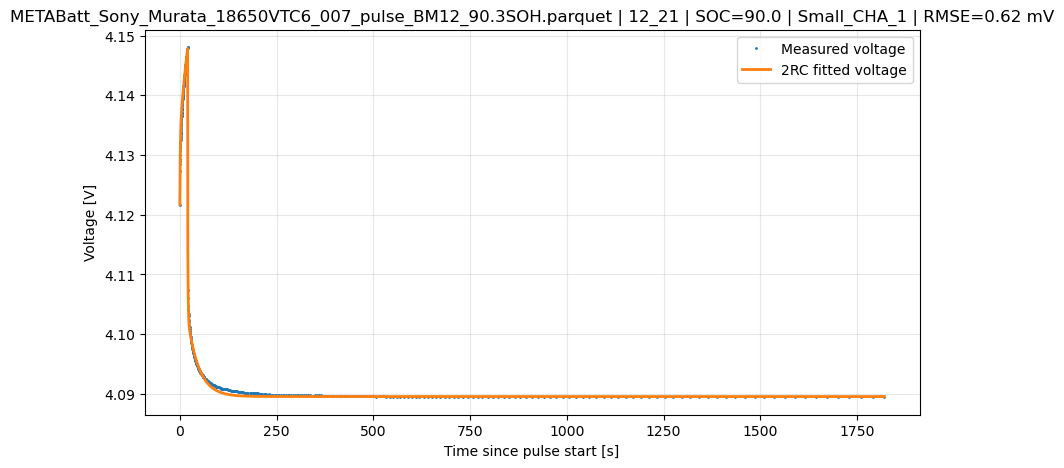

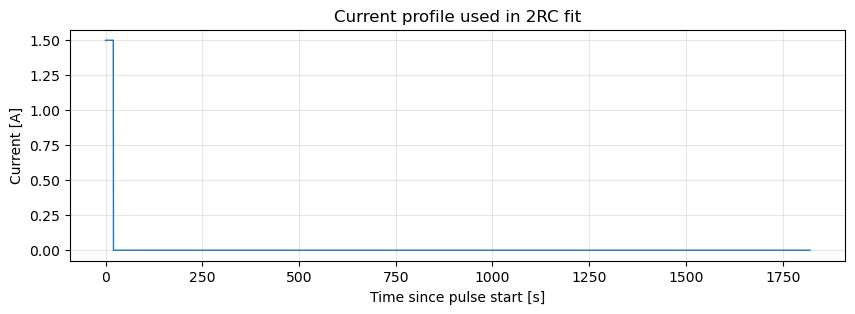

In [ ]:

# =====================================================================
# Cell 4: 可选绘图 - 检查某一个 pulse + following PAU 的二阶 RC 拟合效果
# =====================================================================
# 使用方法：运行 Cell 3 后，修改 SAMPLE_INDEX，查看对应脉冲的实测电压与拟合电压。
# 该 Cell 只是质量检查，不影响参数输出。
# =====================================================================

import matplotlib.pyplot as plt

SAMPLE_INDEX = 0  # 可修改为 df_r0r1r2 中其他行号

if 'df_r0r1r2' not in globals() or len(df_r0r1r2) == 0:
    print("没有可绘制的 df_r0r1r2 结果。")
else:
    row = df_r0r1r2.iloc[SAMPLE_INDEX]
    src_file = row['Source_File']
    pulse_id = row['Pulse_ID']
    pau_id = row['Following_PAU_ID']
    pulse_df, pau_raw, fit_df = _make_fit_segment(df_rc2_work, src_file, pulse_id, pau_id)

    ocv_before = row['OCV_before_prev_PAU_end']
    ocv_after = row['OCV_after_following_PAU_end']
    fit_df = fit_df.sort_values('Time_dt').reset_index(drop=True)
    t0 = fit_df['Time_dt'].iloc[0]
    t_s = (fit_df['Time_dt'] - t0).dt.total_seconds().astype(float).values
    I = pd.to_numeric(fit_df['Current'], errors='coerce').astype(float).values
    V_meas = pd.to_numeric(fit_df['Voltage'], errors='coerce').astype(float).values
    ocv_profile = _cumulative_ocv_profile(fit_df, pulse_df, ocv_before, ocv_after)

    V_fit, V1_fit, V2_fit = _simulate_2rc(
        t_s, I, row['R0_Ohm'], row['R1_Ohm'], row['R2_Ohm'], row['Tau1_s'], row['Tau2_s'], ocv_profile
    )

    plt.figure(figsize=(10, 5))
    plt.plot(t_s, V_meas, '.', markersize=2, label='Measured voltage')
    plt.plot(t_s, V_fit, '-', linewidth=2, label='2RC fitted voltage')
    plt.xlabel('Time since pulse start [s]')
    plt.ylabel('Voltage [V]')
    plt.title(f"{src_file} | {pulse_id} | SOC={row['SOC']} | {row['Pulse_Role']} | RMSE={row['Fit_RMSE_mV']:.2f} mV")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    plt.figure(figsize=(10, 3))
    plt.plot(t_s, I, '-', linewidth=1)
    plt.xlabel('Time since pulse start [s]')
    plt.ylabel('Current [A]')
    plt.title('Current profile used in 2RC fit')
    plt.grid(True, alpha=0.3)
    plt.show()


## Cell 5: Resistance vs SOH plots by SOC and pulse role

追加绘图部分：不同 SOC 用颜色区分，同一 SOC 下不同脉冲用 marker / line dash 区分。

In [ ]:
# =====================================================================
# Cell 5: 按 SOC / Pulse Role 绘制 R0、R1、R2 与 SOH 的关系
# =====================================================================
# 绘图要求：
#   X axis: SOH [%]，从高到低降序显示；
#   Y axis: Resistance [mOhm]
#   不同 SOC 用不同颜色区分；
#   同一 SOC 下不同 pulse role 用不同 marker 区分；
#   图形类型：散点图，不再用连线。
#
# 当前三脉冲 cycle 输出三组图：
#   1) 小电流充电脉冲：Small_CHA_1
#   2) 两个大电流脉冲：HighCurrent_DCH_3A vs HighCurrent_CHA_3A
#   3) 三个有效 pulse：Small_CHA_1, HighCurrent_DCH_3A, HighCurrent_CHA_3A
#
# 每组分别绘制：R0_mOhm, R1_mOhm, R2_mOhm。
# =====================================================================

import numpy as np
import pandas as pd
from pathlib import Path
from IPython.display import display
import plotly.express as px

if 'df_r0r1r2' not in globals():
    raise RuntimeError('请先运行 Cell 3，生成 df_r0r1r2 后再运行本绘图 Cell。')
if df_r0r1r2 is None or len(df_r0r1r2) == 0:
    raise RuntimeError('df_r0r1r2 为空，无法绘图。请先检查 Cell 3 的二阶 RC 拟合结果。')

# -----------------------------
# 绘图设置
# -----------------------------
PLOT_ONLY_RC2_OK = True       # True: 只绘制 RC2_Quality_Flag 为空的结果
PLOT_ONLY_FIT_SUCCESS = True  # True: 只绘制 Fit_Success == True 的结果
SHOW_POINT_LABELS = False     # True: 在点旁边显示 pulse 简短标签，数据多时可能较拥挤
SAVE_HTML = True

plot_output_dir = Path('R0R1R2_extraction_outputs') / 'plots_scatter_resistance_vs_SOH_descending_by_SOC_and_pulse'
plot_output_dir.mkdir(parents=True, exist_ok=True)

# -----------------------------
# 准备绘图数据
# -----------------------------
plot_df = df_r0r1r2.copy()

# 基础列检查
required_cols = ['SOH', 'SOC', 'Pulse_Role']
missing_required = [c for c in required_cols if c not in plot_df.columns]
if missing_required:
    raise RuntimeError(f'df_r0r1r2 缺少必要列: {missing_required}')

# 只画质量通过的数据
if PLOT_ONLY_RC2_OK and 'RC2_Quality_Flag' in plot_df.columns:
    plot_df = plot_df[plot_df['RC2_Quality_Flag'].fillna('').astype(str).str.strip() == ''].copy()

if PLOT_ONLY_FIT_SUCCESS and 'Fit_Success' in plot_df.columns:
    plot_df = plot_df[plot_df['Fit_Success'].fillna(False).astype(bool)].copy()

# 数值化
plot_df['SOH'] = pd.to_numeric(plot_df['SOH'], errors='coerce')
plot_df['SOC'] = pd.to_numeric(plot_df['SOC'], errors='coerce')
for col in ['R0_mOhm', 'R1_mOhm', 'R2_mOhm']:
    if col in plot_df.columns:
        plot_df[col] = pd.to_numeric(plot_df[col], errors='coerce')

# SOC 和 pulse 显示标签
plot_df['SOC_label'] = plot_df['SOC'].map(lambda x: f'{int(x)}% SOC' if pd.notna(x) else 'SOC unknown')

role_label_map = {
    'Small_CHA_1': 'Small CHA 1.5A',
    'HighCurrent_DCH_3A': 'High DCH 3A',
    'HighCurrent_CHA_3A': 'High CHA 3A',
}
plot_df['Pulse_Label'] = plot_df['Pulse_Role'].map(role_label_map).fillna(plot_df['Pulse_Role'].astype(str))
plot_df['Point_Label'] = plot_df['Pulse_Label'].str.replace('HighCurrent_', '', regex=False)

# 推荐的固定顺序
soc_order = ['90% SOC', '50% SOC', '10% SOC']
pulse_order = [
    'Small CHA 1.5A',
    'High DCH 3A',
    'High CHA 3A',
]

# 三组对比
plot_groups = {
    '01_small_current_CHA': {
        'title': 'Group 1: small-current charge pulse CHA1 (1.5A)',
        'roles': ['Small_CHA_1'],
    },
    '02_high_current_DCH_vs_CHA': {
        'title': 'Group 2: high-current pulses DCH1 (3A) vs CHA2 (3A)',
        'roles': ['HighCurrent_DCH_3A', 'HighCurrent_CHA_3A'],
    },
    '03_all_three_valid_pulses': {
        'title': 'Group 3: all three valid pulses in each SOC cycle',
        'roles': ['Small_CHA_1', 'HighCurrent_DCH_3A', 'HighCurrent_CHA_3A'],
    },
}
resistance_columns = [c for c in ['R0_mOhm', 'R1_mOhm', 'R2_mOhm'] if c in plot_df.columns]
if not resistance_columns:
    raise RuntimeError('df_r0r1r2 中没有 R0_mOhm / R1_mOhm / R2_mOhm 列，无法绘图。')

# 保存用于绘图的数据，方便之后检查
plot_data_path = plot_output_dir / 'plot_data_R0R1R2_by_SOC_pulse.csv'
plot_df.to_csv(plot_data_path, index=False, encoding='utf-8-sig')
print(f'📌 用于绘图的数据已保存: {plot_data_path}')

# -----------------------------
# 绘图函数
# -----------------------------
def _make_resistance_plot(data, y_col, group_key, group_title):
    df = data.dropna(subset=['SOH', 'SOC', y_col]).copy()
    if len(df) == 0:
        print(f'⚠️ {group_title} | {y_col}: 无可绘制数据。')
        return None

    df = df.sort_values(['SOC', 'Pulse_Label', 'SOH'], ascending=[False, True, False]).copy()

    fig = px.scatter(
        df,
        x='SOH',
        y=y_col,
        color='SOC_label',                 # 不同 SOC 用不同颜色
        symbol='Pulse_Label',              # 同 SOC 不同 pulse 用不同 marker
        text='Pulse_Label' if SHOW_POINT_LABELS else None,
        category_orders={
            'SOC_label': soc_order,
            'Pulse_Label': pulse_order,
        },
        hover_data={
            'SOH': ':.2f',
            'SOC': True,
            'Pulse_Role': True,
            y_col: ':.4f',
            'Source_File': True if 'Source_File' in df.columns else False,
            'Pulse_ID': True if 'Pulse_ID' in df.columns else False,
            'Fit_RMSE_mV': ':.3f' if 'Fit_RMSE_mV' in df.columns else False,
            'RC2_Quality_Flag': True if 'RC2_Quality_Flag' in df.columns else False,
        },
        title=f'{group_title}: {y_col} vs SOH by SOC and pulse role',
        labels={
            'SOH': 'SOH [%]',
            y_col: f'{y_col.replace("_mOhm", "")} [mΩ]',
            'SOC_label': 'SOC',
            'Pulse_Label': 'Pulse role',
        },
    )

    fig.update_traces(marker=dict(size=8, opacity=0.85))
    if SHOW_POINT_LABELS:
        fig.update_traces(textposition='top center')

    fig.update_layout(
        template='plotly_white',
        width=1050,
        height=650,
        legend_title_text='SOC / Pulse role',
        xaxis_title='SOH [%]',
        yaxis_title=f'{y_col.replace("_mOhm", "")} [mΩ]',
    )
    fig.update_xaxes(showgrid=True, autorange='reversed')
    fig.update_yaxes(showgrid=True)

    if SAVE_HTML:
        html_path = plot_output_dir / f'{group_key}_{y_col}_vs_SOH.html'
        fig.write_html(html_path)
        print(f'💾 图已保存: {html_path}')

    fig.show()
    return fig

# -----------------------------
# 生成三组图
# -----------------------------
print('\n📌 绘图数据数量统计：')
display(
    plot_df
    .groupby(['SOC', 'Pulse_Role'], dropna=False)
    .size()
    .reset_index(name='Count')
    .sort_values(['SOC', 'Pulse_Role'], ascending=[False, True])
)

figures = {}
for group_key, spec in plot_groups.items():
    roles = spec['roles']
    group_title = spec['title']
    group_df = plot_df[plot_df['Pulse_Role'].isin(roles)].copy()

    print(f'\n============================================================')
    print(f'📊 {group_title}')
    print(f'Pulse roles: {roles}')
    print(f'Rows: {len(group_df)}')

    if len(group_df) == 0:
        print('⚠️ 该组没有可绘制数据，跳过。')
        continue

    display(
        group_df
        .groupby(['SOC', 'Pulse_Label'], dropna=False)
        .size()
        .reset_index(name='Count')
        .sort_values(['SOC', 'Pulse_Label'], ascending=[False, True])
    )

    for y_col in resistance_columns:
        fig = _make_resistance_plot(group_df, y_col, group_key, group_title)
        if fig is not None:
            figures[(group_key, y_col)] = fig

print('\n✅ 三组 SOC/SOH 电阻对比图已生成。')
print(f'HTML 图文件目录: {plot_output_dir}')
print('说明：颜色区分 SOC；marker 区分同 SOC 下不同 pulse role；X 轴 SOH 为高到低降序；图形为散点图。')


📌 用于绘图的数据已保存: R0R1R2_extraction_outputs\plots_scatter_resistance_vs_SOH_descending_by_SOC_and_pulse\plot_data_R0R1R2_by_SOC_pulse.csv

📌 绘图数据数量统计：


,SOC,Pulse_Role,Count
6,90.0,HighCurrent_CHA_3A,5
7,90.0,HighCurrent_DCH_3A,21
8,90.0,Small_CHA_1,21
3,50.0,HighCurrent_CHA_3A,19
4,50.0,HighCurrent_DCH_3A,20
5,50.0,Small_CHA_1,20
0,10.0,HighCurrent_CHA_3A,22
1,10.0,HighCurrent_DCH_3A,19
2,10.0,Small_CHA_1,21



📊 Group 1: small-current charge pulse CHA1 (1.5A)
Pulse roles: ['Small_CHA_1']
Rows: 62


,SOC,Pulse_Label,Count
2,90.0,Small CHA 1.5A,21
1,50.0,Small CHA 1.5A,20
0,10.0,Small CHA 1.5A,21


💾 图已保存: R0R1R2_extraction_outputs\plots_scatter_resistance_vs_SOH_descending_by_SOC_and_pulse\01_small_current_CHA_R0_mOhm_vs_SOH.html


...

,SOC,Pulse_Label,Count
6,90.0,High CHA 3A,5
7,90.0,High DCH 3A,21
8,90.0,Small CHA 1.5A,21
3,50.0,High CHA 3A,19
4,50.0,High DCH 3A,20
5,50.0,Small CHA 1.5A,20
0,10.0,High CHA 3A,22
1,10.0,High DCH 3A,19
2,10.0,Small CHA 1.5A,21


💾 图已保存: R0R1R2_extraction_outputs\plots_scatter_resistance_vs_SOH_descending_by_SOC_and_pulse\03_all_three_valid_pulses_R0_mOhm_vs_SOH.html


💾 图已保存: R0R1R2_extraction_outputs\plots_scatter_resistance_vs_SOH_descending_by_SOC_and_pulse\03_all_three_valid_pulses_R1_mOhm_vs_SOH.html


💾 图已保存: R0R1R2_extraction_outputs\plots_scatter_resistance_vs_SOH_descending_by_SOC_and_pulse\03_all_three_valid_pulses_R2_mOhm_vs_SOH.html



✅ 三组 SOC/SOH 电阻对比图已生成。
HTML 图文件目录: R0R1R2_extraction_outputs\plots_scatter_resistance_vs_SOH_descending_by_SOC_and_pulse
说明：颜色区分 SOC；marker 区分同 SOC 下不同 pulse role；X 轴 SOH 为高到低降序；图形为散点图。
